# 详解模型推理


## 衡量infer的标准
Time-to-first-token (TTFT): how long user waits before any generation happens (matters for interactive applications)
    
Latency (seconds/token): how fast tokens appear for a user (matters for interactive applications)
    
Throughput (tokens/second): useful for batch processing applications

## 推理效率
Key considerations in efficiency:
    
Training (supervised): you see all tokens, can parallelize over sequence (matmul in Transformer)
    
Inference: you have to generate sequentially, can't parallelize, so harder to fully utilize compute


## transformer模型的推理负载
下图中，一般 F = 4*D, D = N*H, N = K*G, S = T
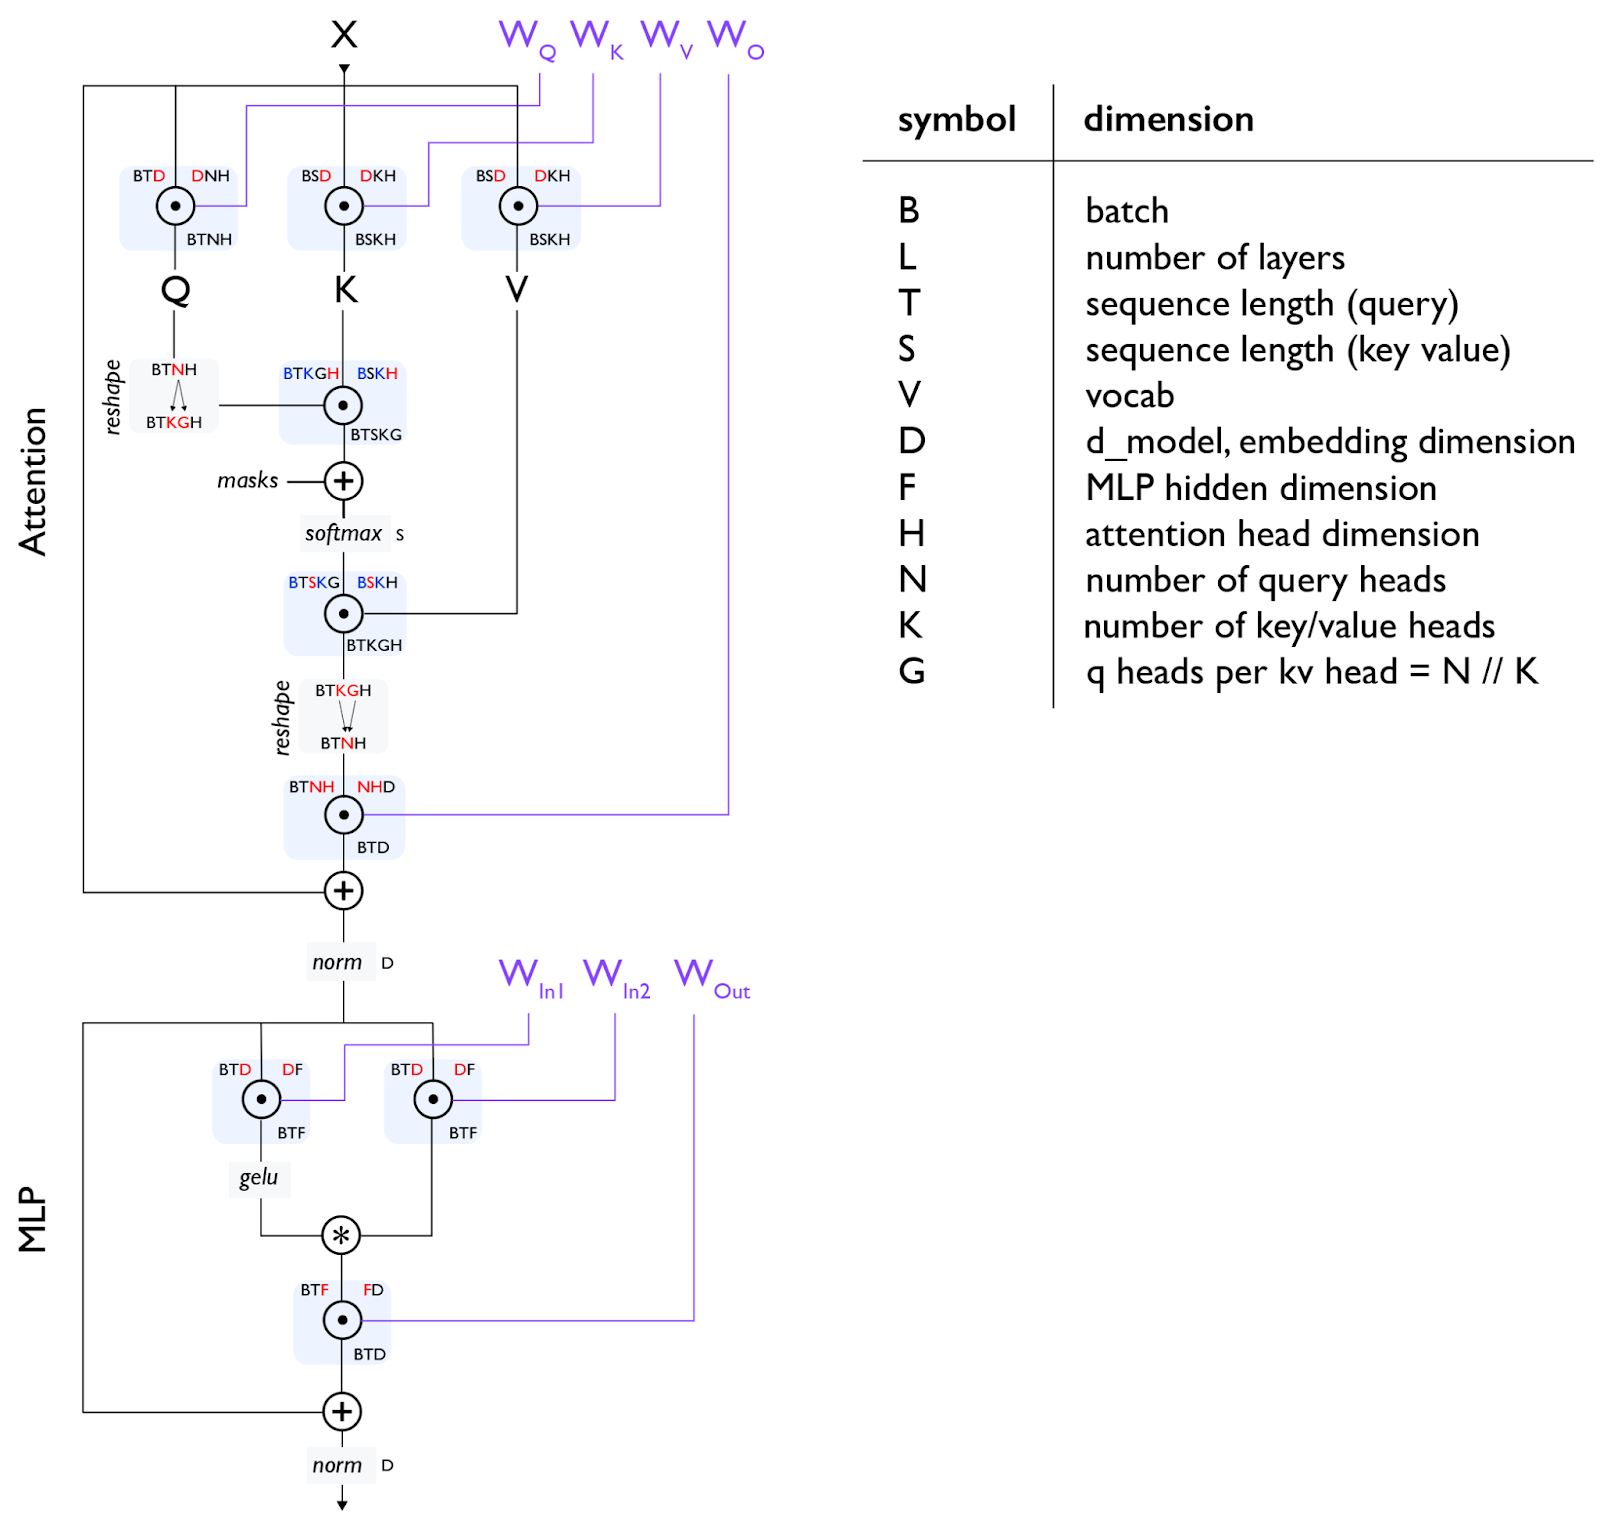
**FLOPs for a feedforward pass: 6 * (B*T) * (num_params + O(T))**

### arithmetic intemsity
 - setup:multiply X(B,D) and W(D,F)matrix
 - intuition :B is batch size,D is hidden dimension,D is up-projection dimension in MLP

 - Let's do FLOPS and memory read/write accounting for the matrix multiplication (X * W)


In [2]:
# 初始化
flops = 0  # 计算强度
bytes_transferred = 0   # 内存占用

### steps
 - 假设所有的数据都是bf16
1. Read X(B,D) from HBM(全称是 High Bandwidth Memory，即 高带宽内存,通过 3D堆叠 的方式将多个DRAM芯片垂直堆叠在一起)

`bytes_transferred += 2 * B * D`

2. Read W(D,F) from HBM

`bytes_transferred += 2 * D * F`

3. Compute Y = X(B,D)@W(D,F)

`flops += 2 * B * D * F `

4. Write Y(B,F) to HBM

`bytes_transferred += 2 * B * F`

### 矩阵运算的intensity计算
Let's take stock of the accounting results.
 - assert flops == 2* B * D * F
  - assert bytes_transferred == 2 * B * D + 2 * D * F + 2 * B * F

Recall that arithmetic intensity is how much compute we do per byte transferred (want to be high).
    
**intensity = (flops / bytes_transferred).simplify()  # @inspect intensity**
    
<mark>Assuming B is much less than D and F, then we can simplify</mark>:
    
**intensity = intensity.subs(D, c * B).subs(F, c * B).limit(c, oo).simplify()  # @inspect intensity**

#### assert intensity == B ，此时intensity仅仅取决于batch size这一个变量

### 计算A100的accelerator intensity 看是否可以满足该矩阵乘法的intensity
 Accelerator intensity of H100:
 - flops_per_second = 989e12
 - memory_bandwidth = 3.35e12
 - accelerator_intensity = flops_per_second / memory_bandwidth  # @inspect accelerator_intensity
 - assert round(accelerator_intensity) == 295

### 结论
 - computation intensity > accelerator intensity, compute-limited (good) 
    - 这个就证明充分利用了GPU/TPU的计算资源
 - computation intensity < accelerator intensity, memory-limited (bad)
    - 这个就证明了内存是瓶颈（内存受限）
 - **Conclusion: compute-limited iff B > 295**


### 比较坏的情况Extreme case (B = 1, corresponding to matrix-vector product):
    
Arithmetic intensity: 1
    
Memory-limited (read D x F matrix, perform only 2DF FLOPs)
    
This is basically what happens with generation...

### arithmetic_intensity_of_inference
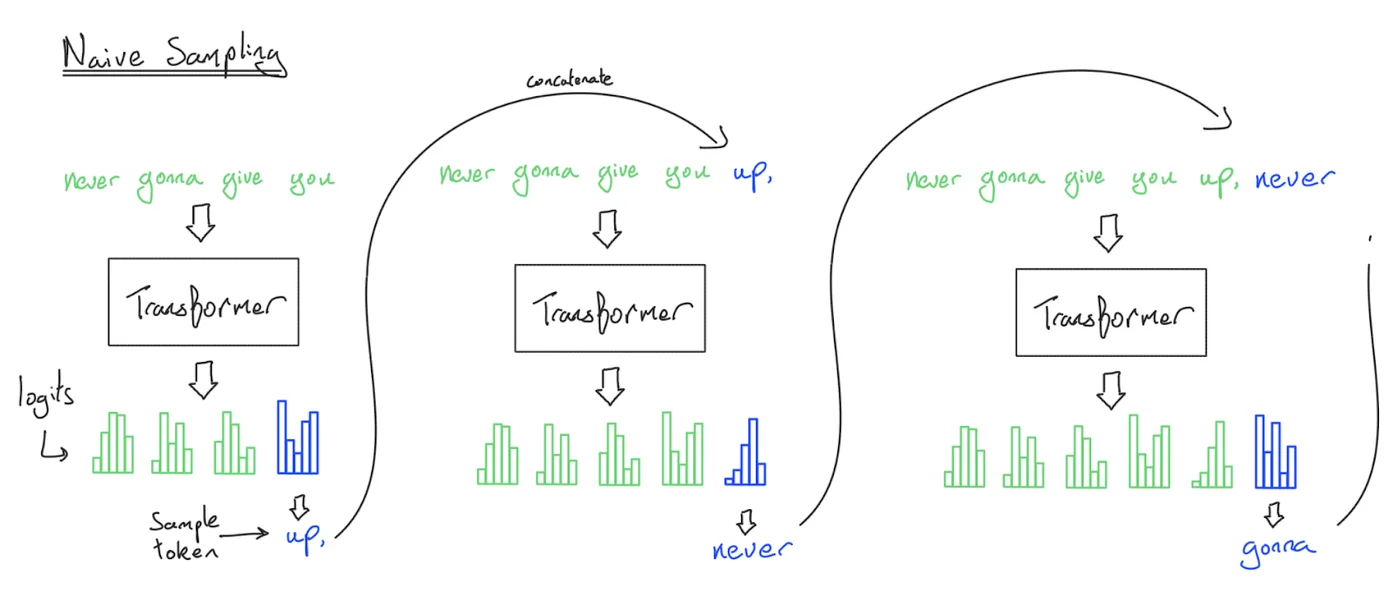
Naive inference: to generate each token, feed history into Transformer
 - Complexity: generating T tokens requires O(T^3) FLOPs (one feedforward pass is O(T^2))


### solution: store KV cache in HBM
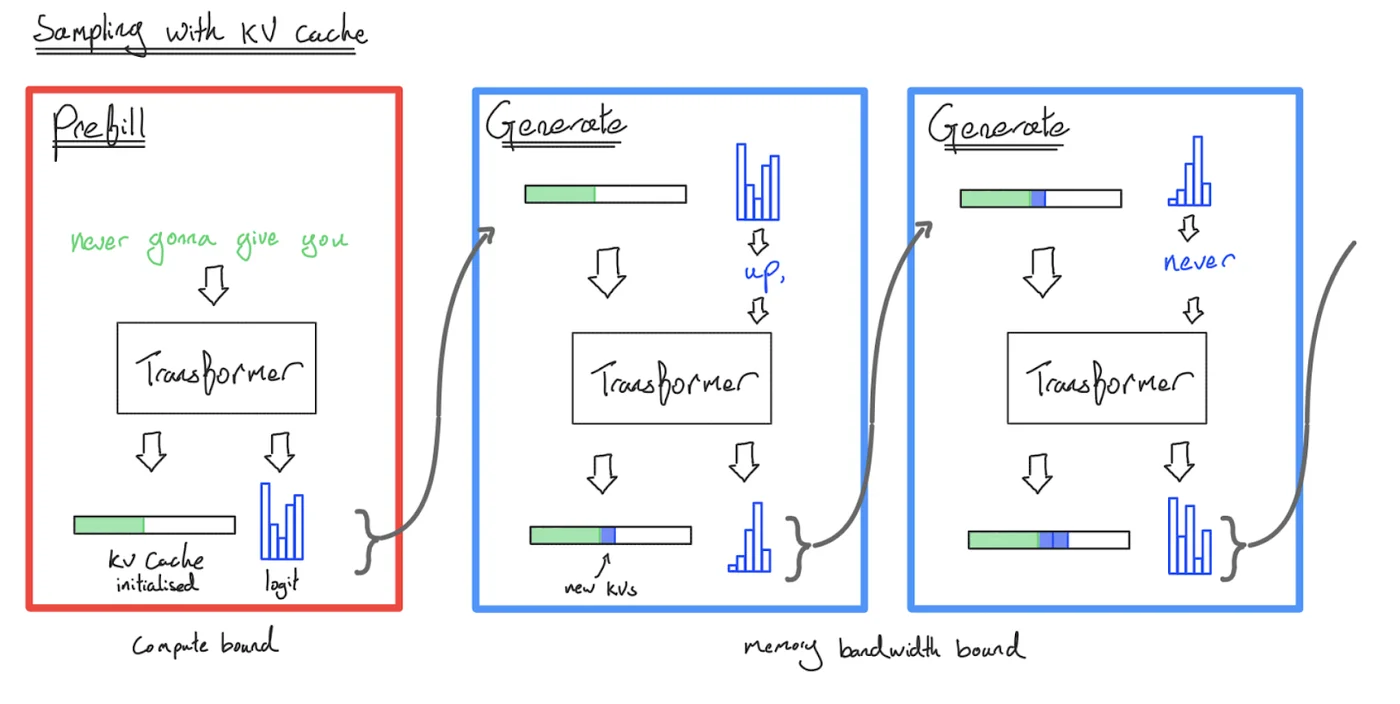
KV cache: for every sequence (B), token (S), layer (L), head (K), store an H-dimensional vector

### Two stages of inference:
    
 - Prefill: given a prompt, encode into vectors (parallelizable like in training) 
 - Generation: generate new response tokens (sequential)

### compute the FLOPS and memory IO for both the MLP and the attention layers
S is the number of tokens we're conditioning on, T is the number of tokens we'er generating

In [ ]:
flops = 0
bytes_transferred = 0

# steps
# 1. Read X(B,T,D) from HBM
bytes_transferred += 2 * B * T * D

# 2, Read Wup(D,F),Wgate(D,F),Wdown(F,D) from HBM
bytes_transferred +=3 * 2 * D * F

# 3. Compute U = X(B,T,D) @ Wup(D,F)
flops += 2 * B * T * D * F

# 4. Write U(B,T,F) to HBM
bytes_transferred += 2 * B * T * F

# 5. Compute G = X(B,T,D) @ Wgate(D,F)
flops += 2 * B * T * D * F

# 6. write G(B,T,F) to HBM
bytes_transferred += 2 * B * T * F

# 7. Compute Y = GELU(G)* U(B,T,F) @ Wdown(F,D)
flops += 2 * B * T * D * F

# 8. Write Y(B,T,D) to HBM
bytes_transferred += 2 * B * T * D 


**汇总**

* FLOPs：$6\cdot B\cdot T\cdot D\cdot F$（三次 matmul 各 $2B T D F$）
* 字节：读取+写回：

  $$
  \underbrace{2B T D}_{X} + 
  \underbrace{3\cdot 2 D F}_{W} + 
  \underbrace{2B T F}_{U} + 
  \underbrace{2B T F}_{G} + 
  \underbrace{2B T D}_{Y}
  = 4B T D + 4B T F + 6 D F
  $$
* **算术强度（Arithmetic Intensity）**：

  $$
  \frac{\text{FLOPs}}{\text{Bytes}}
  = \frac{6 B T D F}{\,4B T D + 4B T F + 6 D F\,}
  $$

  当 $D,F\gg B T$（典型大模型），令 $D=F=c\cdot B T$，$c\to\infty$：

  $$
  \frac{6 B T (cBT)^2}{\,4BT(cBT)+4BT(cBT)+6(cBT)^2\,}
  \xrightarrow[c\to\infty]{}\frac{6 c^2 B^3 T^3}{\,6 c^2 B^2 T^2\,}=B T
  $$

  即 **MLP 强度 $\approx B\cdot T$**。

  * **Prefill（$T=S$ 大）**：只要 $B T$ 足够大，就容易**算力受限（compute-bound）**。
  * **Generation（$T=1$）**：强度 $\approx B$。想算力受限就得把 **并发请求数 $B$** 堆高，这在真实在线服务里常是瓶颈。

> 直觉：MLP 的权重对所有序列共享，**同一份权重可被大量 token 复用**；增加 $B$ 或 $T$ 能把固定的权重读开销摊薄，因此强度随 $B T$ 增长。




### compute_transformer_stats

In [ ]:
flops = 0
bytes_transferred = 0

# steps
# 1. Read Q(B,T,D),K(B,S,D),V(B,S,D) from HBM
bytes_transferred += 2 * ( B * T * D + 2 * B * S * D)

# 2. Compute A = Q(B,T,D) @ K(B,S,D)
flops += 2 * B * T * S * D

# 3. Compute Y = A(B,S,T,D) @ V(B,S,D)
flops += 2 * B * T * S * D

# 4. write back Y(B,S,T,D)to HBM
bytes_transferred += 2 * B * T * D

**汇总**

* FLOPs：$4\cdot B\cdot S\cdot T\cdot D$
* 字节：$(2BTD + 2BSD + 2BSD) + 2BTD = 4BTD + 4BSD$
* **算术强度**：

  $$
  \frac{4BSTD}{\,4BTD+4BSD\,}
  = \frac{ST}{\,S+T\,}
  $$

  * **Prefill（$T=S$）**：强度 $= S/2$。序列越长，越**算力受限（好事）**。
  * **Generation（$T=1$）**：强度 $= \frac{S}{S+1}<1$。这是**内存受限**：每算一点点，都得从 HBM 把整段 $K,V$ 拉进来。

> 直觉：注意力里 **$K,V$ 是每条序列独有的 KV Cache**，随着 $B,S$ 线性增长，且无法在不同请求之间共享；即使你把 $B$ 堆大，读入的 $K,V$ 也同步增大，**强度不会随 $B$ 改善**。这与 MLP 形成鲜明对比（MLP 权重共享，可被批量复用）。

---
 - MLP：

   - 权重 不依赖 batch，可以被所有请求复用。

   - 批处理有助于提升算术强度 → 批越大越好。

 - Attention：

   - KV 缓存 依赖 batch，每个请求独立一份。

   - 批处理不会改善算术强度 → 再大也帮不上忙

### 结论对齐（与你给出的断言）

* **MLP**
  $\text{FLOPs}=6BTDF$（✅）
  $\text{Bytes}=4BTD+4BTF+6DF$（✅）
  强度在 $D,F\gg BT$ 时 $\to BT$（✅）。

  * Prefill：可算力受限（把 $BT$ 做大）。
  * Generation：强度 $\approx B$，需要大量并发请求才可能算力受限。
* **Attention（FlashAttention 记账）**
  $\text{FLOPs}=4BSTD$（✅）
  $\text{Bytes}=4BSD+4BTD$（✅）
  强度 $=\dfrac{ST}{S+T}$（✅）。

  * Prefill：$S/2$（✅，不错）。
  * Generation：$S/(S+1)<1$（✅，内存受限）。批量不帮忙（因为 KV 不共享）。



**推理的瓶颈在于generation的时候的内存受限**

# throughtput and latency
假设: can overlap compute and communication perfectly and ignore various types of overhead.





## 1. 函数 `compute_transformer_stats(config)`

这个函数的目标是：**根据 Transformer 的超参数，推导出参数量、显存占用、延迟和吞吐率**。

---

### (1) 参数量计算

```python
num_params = 2*V*D + D*F*3*L + (2*D*N*H + 2*D*K*H)*L
```

含义：

* **$V$**：词表大小。
* **$D$**：隐藏维度（embedding 维度）。
* **$F$**：MLP 中间维度。
* **$L$**：层数。
* **$N$**：头数（Q/K/V 投影矩阵的数量）。
* **$K$**：每个注意力头的维度。
* **$H$**：组的数量（例如 Grouped-Query Attention 的分组）。

拆开解释：

* `2*V*D` ：词嵌入和输出 embedding 矩阵（输入/输出 embedding 参数）。
* `D*F*3*L` ：每层 MLP 需要三组矩阵（Wup, Wgate, Wdown），所以乘 3。
* `(2*D*N*H + 2*D*K*H)*L` ：注意力部分，分别对应 **Q/K/V 投影 + 输出投影**，系数 2 表示权重和偏置。

---

### (2) 参数显存大小

```python
parameter_size = num_params * 2  # 2 for bf16
```

* 每个参数存成 **bf16**，占 2 字节。
* （注：如果是训练，还得存梯度和优化器状态，但这里假设推理，不需要这些）。

---

### (3) KV Cache 占用

```python
kv_cache_size = S * (K*H) * L * 2 * 2
```

* $S$：序列长度（context 长度）。
* $K*H$：每个注意力层存的 key 向量总维度。
* `*L` ：所有层都要存 KV。
* 第一个 `*2` ：Key + Value 两份缓存。
* 第二个 `*2` ：bf16，每元素 2 字节。

---

### (4) 总显存占用

```python
memory = B * kv_cache_size + parameter_size
```

* **$B$**：并发请求数。
* 总显存 = 参数占用 + $B$ 个序列的 KV cache 占用。

---

### (5) 延迟（Latency）

```python
latency = memory / memory_bandwidth
```

* 近似假设：每次生成 token 都要从显存里把 **参数+KV cache** 都读一遍。
* 延迟 ≈ 内存传输量 ÷ 显存带宽。

---

### (6) 吞吐率（Throughput）

```python
throughput = B / latency
```

* 同时在生成 $B$ 个请求，每个请求生成一个 token。
* 吞吐率 = 每次延迟内可以产出的 token 数。

---

## 2. `llama2_13b_config` 配置

```python
def llama2_13b_config(args={}):
    return {
        S: 1024,         # 序列长度 1024
        D: 5120,         # 隐藏维度 5120
        F: 13824,        # MLP 中间维度 13824
        N: 40,           # 注意力头数
        K: 40,           # 每个注意力头的维度
        H: 128,          # 分组数量
        L: 40,           # 层数
        V: 32000,        # 词表大小
        memory_bandwidth: 3.35e12,  # 显存带宽（字节/秒）
        **args
    }
```

这就是 **LLaMA2-13B** 模型的大致配置：

* 40 层，隐藏维 5120，FFN 维度 13824。
* 注意力部分：40 个头，每个头 40 维，分 128 组。
* 词表大小 32k。
* 显存带宽假设为 3.35 TB/s。

---

## 3. 最终返回值

```python
return num_params, memory, latency, throughput
```

* **num\_params**：总参数量。
* **memory**：推理需要的总显存。
* **latency**：生成一步的延迟。
* **throughput**：每秒能生成多少 token（在 batch 并行下）。



## 带入一些参数
我已经帮你算好了，把 LLaMA2-13B 在 **H100 (3.35 TB/s 带宽)** 上的结果列出来：

---

### 模型参数量

* **参数总量**：≈ **130 亿参数**
* **参数显存大小（bf16）**：≈ 26.9 GB（包含在下面的总内存里）

---

### Batch size = 1

* **显存需求**：26.9 GB
* **延迟**：≈ 8.0 ms / token
* **吞吐率**：≈ 125 token/s

---

### Batch size = 64

* **显存需求**：79.7 GB
* **延迟**：≈ 23.8 ms / token
* **吞吐率**：≈ 2689 token/s

---

### Batch size = 256

* **显存需求**：240.8 GB
* **延迟**：≈ 71.9 ms / token
* **吞吐率**：≈ 3562 token/s

---

可以看到：

* **Batch 越大**：延迟更高（因为一次要读更多 KV cache），但总吞吐率提升明显。
* **Batch=1** 时最适合低延迟交互场景；
* **Batch=64 或 256** 则适合高吞吐离线生成。




### 1. 延迟 (latency) 和吞吐率 (throughput) 的权衡

* **小 batch**

  * 优点：延迟低（单个请求更快拿到结果）。
  * 缺点：吞吐率低（总的 tokens/s 产出少）。

* **大 batch**

  * 优点：吞吐率高（一次可以并行生成很多请求的 token）。
  * 缺点：延迟高（每个请求都要等更久，响应慢）。

👉 这就是典型的 **延迟 ↔ 吞吐率** 的 tradeoff。

---

### 2. 并行化的两种方式

* **简单的并行（Easy parallelism）**
  启动 **M 份完整的模型副本**（比如在多卡或多机环境）。

  * 延迟：每份模型的延迟不变。
  * 吞吐率：线性增加，提升到原来的 M 倍。

* **复杂的并行（Hard parallelism）**
  把 **一个模型和它的 KV cache 切分 (sharding)**，分布在多个 GPU 上协同工作。

  * 实现更复杂（需要通信、同步）。
  * 但在模型太大、单卡放不下时必须这样做。
  * 这是 Scaling Law 书中讲 Transformer 扩展时的重点。

---

### 3. TTFT (Time-to-First-Token)

* **TTFT = 从输入 prompt 到第一个输出 token 的延迟**。
* 这主要取决于 **prefill 阶段**（模型把 prompt 全部过一遍）。
* 如果 prefill 用大 batch，会更慢 → TTFT 高；
* 如果 prefill 用小 batch，会更快 → TTFT 低。

---

### 4. 最佳实践

* **Prefill 阶段**：用小 batch，保证 TTFT 低，用户早点看到第一个 token。
* **Generation 阶段**：用大 batch，把并发请求堆一起跑，提高整体吞吐率。



## 优化infer
### reduce_kv_cache_size(主要瓶颈是KVCache)

#### Grouped-query attention (GQA)
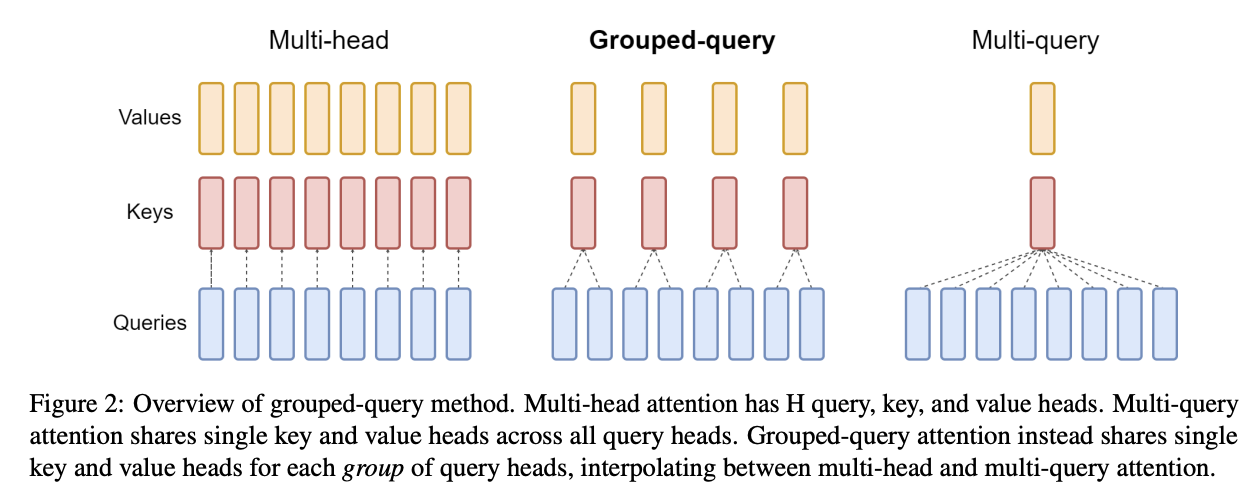
Idea: N query heads, but only K key and value heads, each interacting with N/K query heads
 - Multi-headed attention (MHA): K=N
 - Multi-query attention (MQA): K=1
 - Group-query attention (GQA): K is somewhere in between
 分组查询注意力（GQA） 是一种折衷方案。它将 N 个查询头分成 K 个组，每个组中的所有查询头共享一个 K 头和 V 头。这里的 K 是一个介于 1 和 N 之间的值。这种设计在计算效率和模型性能之间找到了平衡。
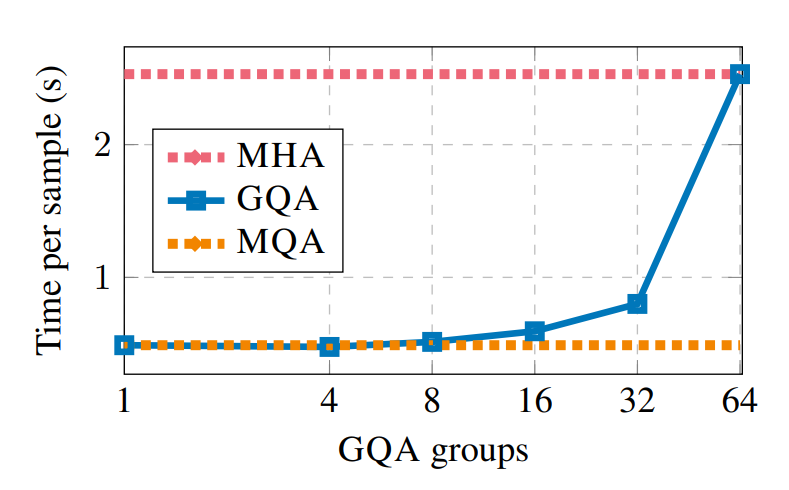
以 llama2_13b 模型为例，我们可以看到 GQA 如何影响性能：

原始模型配置（MHA）：

K=40, B=64：这是一个标准的配置。

k40_memory：占用大量显存。

k40_latency：正常的延迟。

k40_throughput：正常的吞吐量。

使用 GQA：

K=8, B=64：KV 缓存大小减少了 5 倍。

k8_memory：显存占用显著减少，因为 KV 缓存更小了。

k8_latency：延迟可能会略微增加或持平，但主要收益不在于此。

k8_bs_throughput：由于显存更省，我们可以将批量大小提升到 B=256。

更大的批量大小 (B=256)：

k8_bs_memory：尽管批量大小增大，但由于 KV 缓存的优化，它现在可能可以装进显存。

k8_bs_latency：延迟会变差，因为 GPU 需要处理更大的批次。

k8_bs_throughput：吞吐量会大幅提升，因为更大的批次能更好地利用 GPU 的并行计算能力。
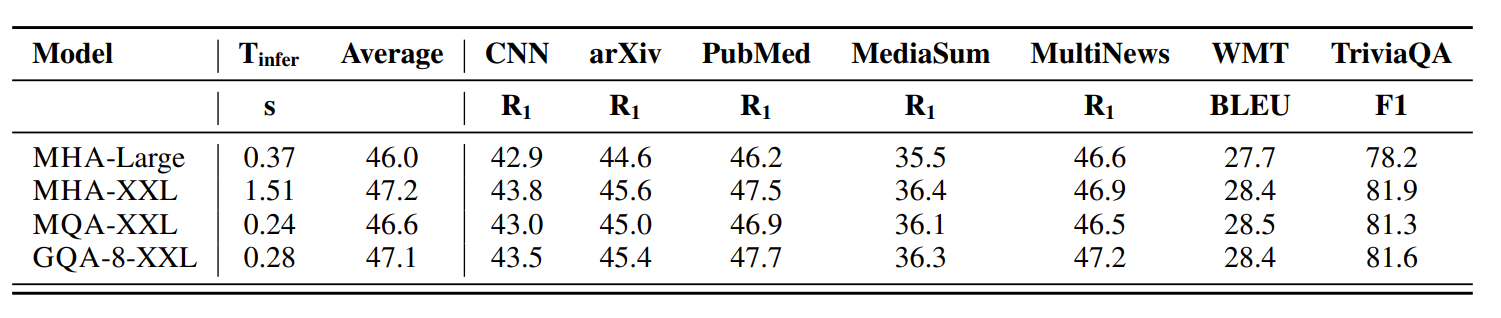

#### Multi-head latent attention (MLA):不改变key value的数量，而是将其投影到低维的向量空间中
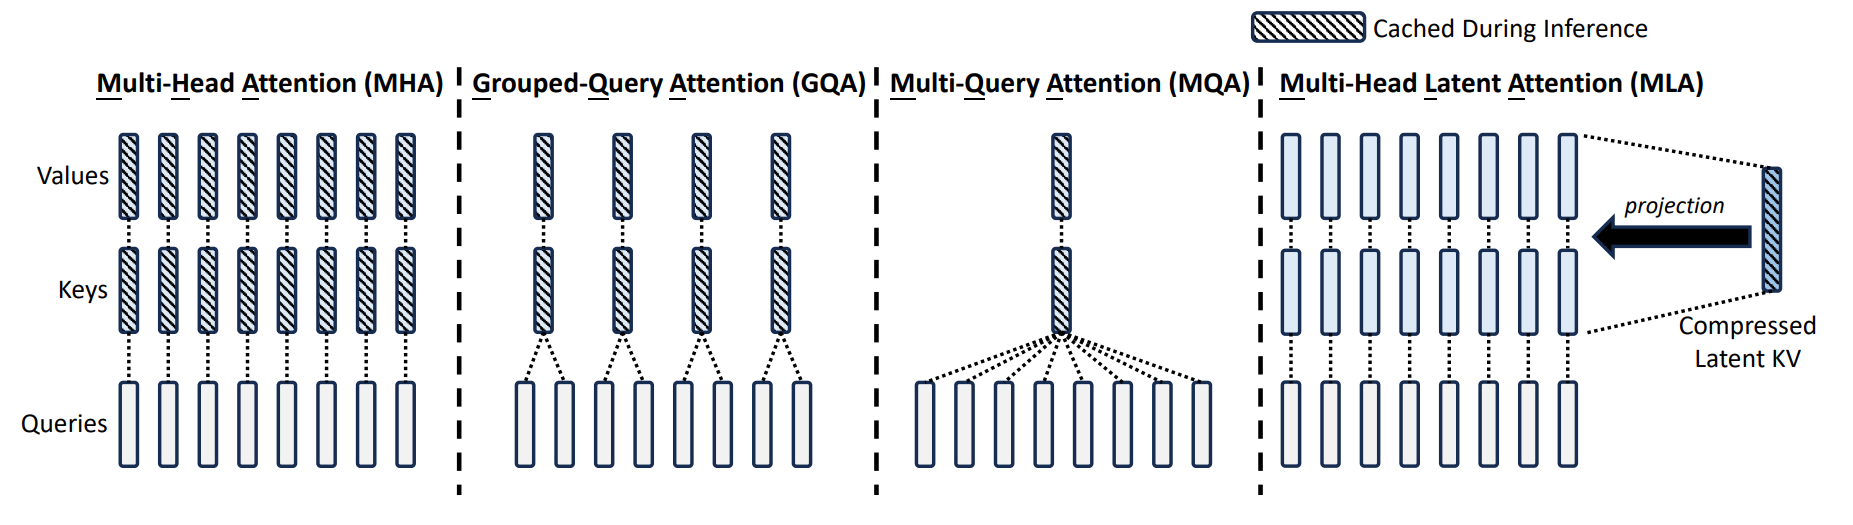
多头潜在注意力（Multi-head Latent Attention, **MLA**）是一种比 GQA 更进一步的注意力机制优化方法，它通过将键（Key）和值（Value）向量的维度大幅降低，来达到减少 KV 缓存和提升推理效率的目的。

---

##### MLA 的核心思想

MLA 的核心是**维度压缩**。它将每个键和值向量的维度从 $N \times H$（其中 $N$ 是头数，`H` 是每个头的维度）压缩到一个小得多的维度 $C$。

以 **DeepSeek v2** 模型为例：

* **原始维度**：$N \times H = 16384$。
* **压缩维度**：$C = 512$。

这意味着每个键和值向量在被保存到 KV 缓存中之前，都会被**线性投影**到一个更小的 512 维空间。这种压缩使得 KV 缓存的大小急剧减小，从而显著降低了内存占用和内存带宽需求，特别是在生成长序列时。

##### 旋转位置编码（RoPE）的特殊处理

一个值得注意的细节是，MLA 与 **旋转位置编码（RoPE）** 存在兼容性问题。RoPE 需要在特定的维度上进行操作以编码位置信息。为了解决这个问题，DeepSeek v2 在压缩后的 512 维向量基础上，额外增加了 64 维来专门处理 RoPE。

因此，最终的键和值向量维度是 $512 + 64 = 576$。

##### 性能与准确率

MLA 带来的性能提升与 GQA 类似，主要体现在**降低 KV 缓存**大小，从而**提升推理吞吐量**。但与 GQA 不同的是，MLA 在**准确率**上表现出了独特的优势。

* **MHA vs. GQA**：MHA 通常比 GQA 具有更高的准确率（虽然成本更高）。这是因为 MHA 有更多的键值对投影，提供了更丰富的表示。GQA 通过牺牲部分准确率来换取效率。
* **MLA vs. MHA**：DeepSeek 团队的研究（[DeepSeek-AI+ 2024]）表明，**MLA 的准确率竟然比 MHA 还要好**，同时计算成本低得多。

**为什么 MLA 能在降维后仍保持甚至超越 MHA 的准确率？**
这可能得益于以下几点：
1.  **更优的压缩投影**：压缩过程本身可以被优化，学习到更高效的特征表示，类似于自编码器（Autoencoder）的概念。
2.  **避免冗余信息**：MHA 中大量的 K/V 投影可能存在冗余，MLA 通过降维可能去除了这些冗余，保留了更本质、更具判别力的信息。
3.  **模型架构的协同设计**：MLA 不是一个孤立的组件，它是与整个 DeepSeek v2 模型架构协同设计的。这种端到端的优化可能使得模型在降维后依然能高效工作。



#### Cross-layer attention (CLA)：本来每层attention之间的Kv矩阵是独立的，现在尝试共享各层中的矩阵
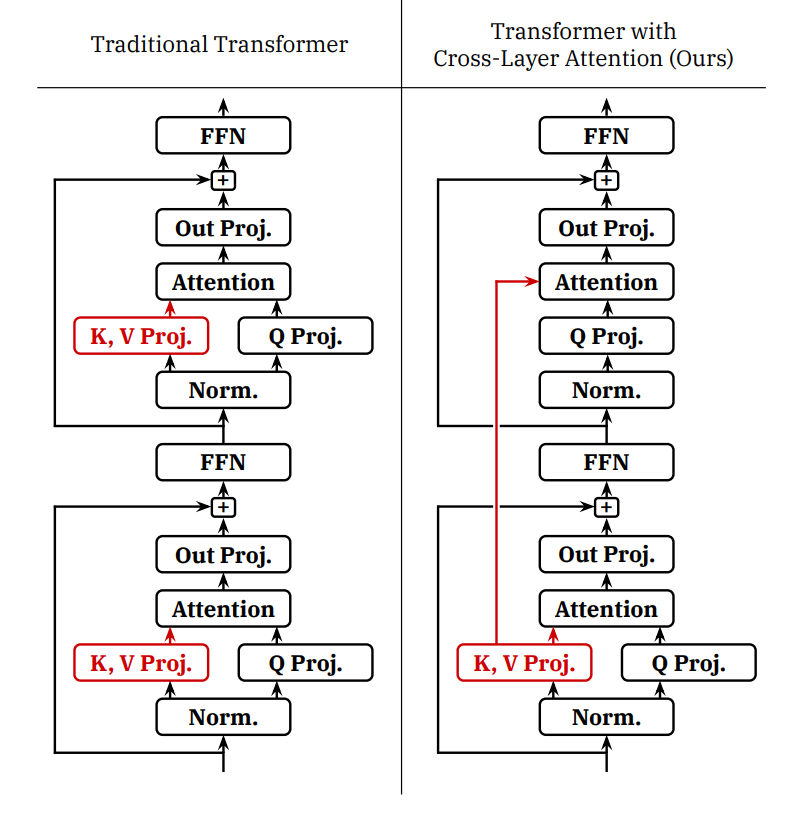
Idea: share KVs across layers (just as GQA shares KVs across heads)
 - Empirically improves the pareto frontier of accuracy and KV cache size (latency and throughput)
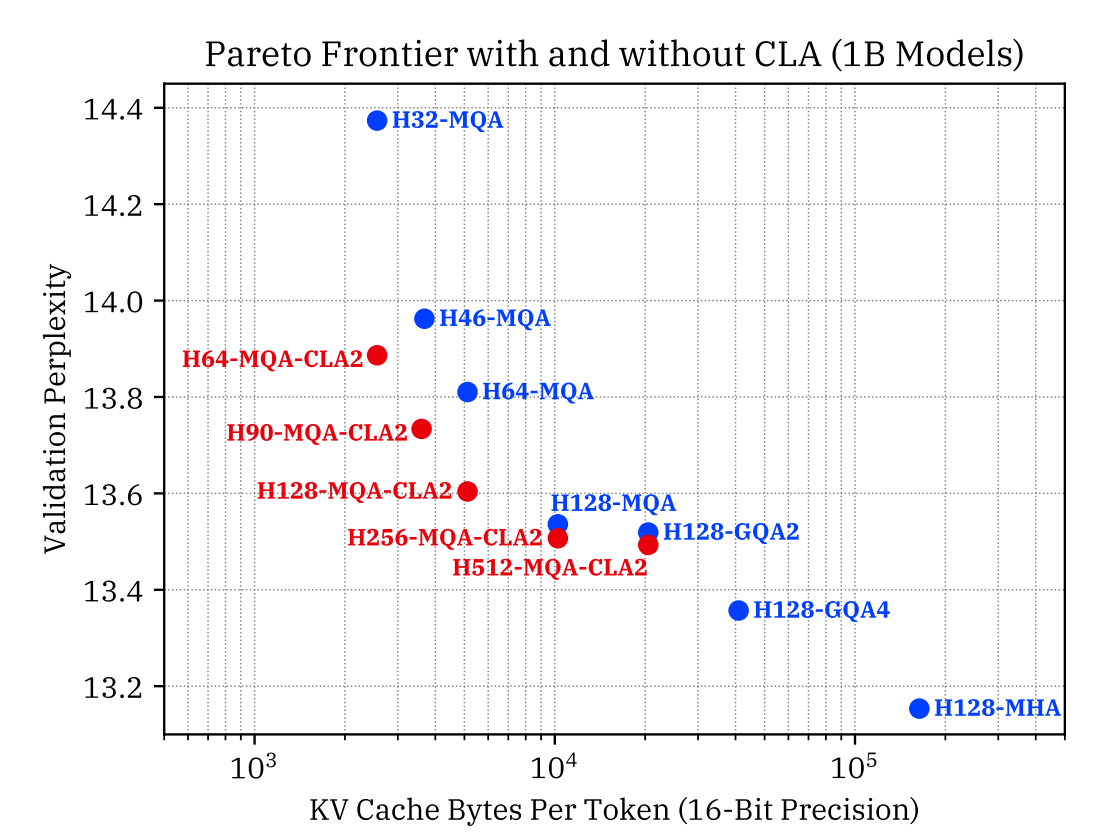

#### Local attention
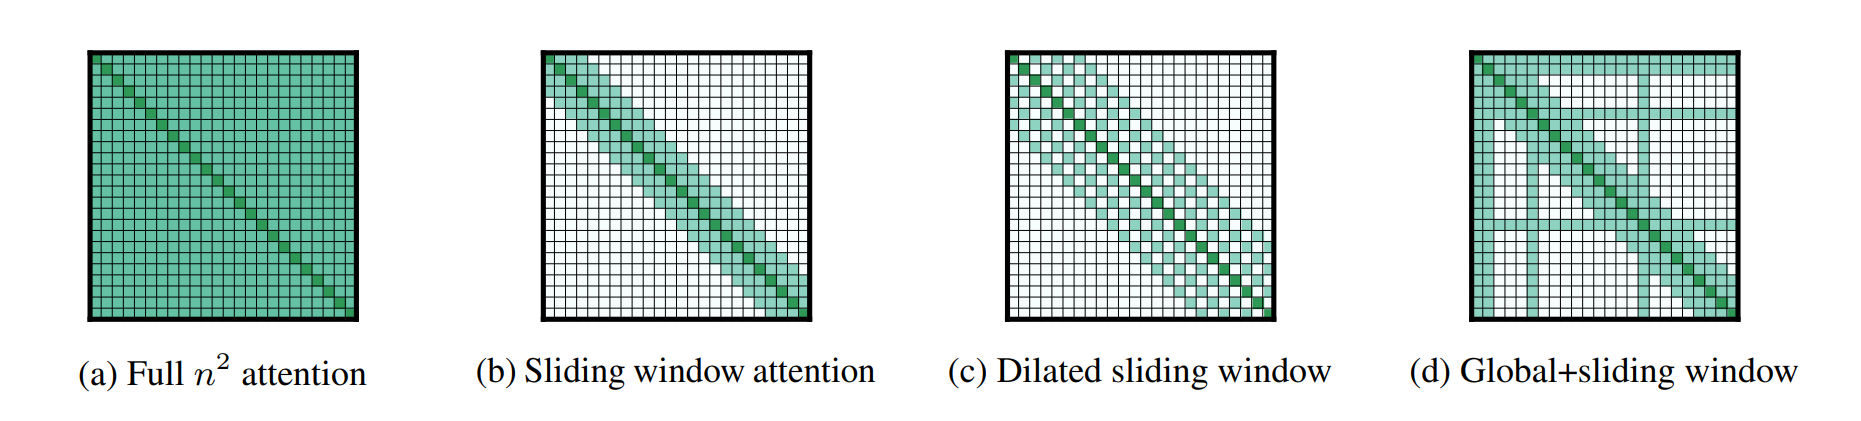
局部注意力（Local Attention）是一种优化长序列推理的注意力机制，其核心思想是，**每个 token 只关注其周围的一个固定大小的上下文窗口，而不是整个序列**。


在传统的注意力机制中，每个 token 都需要计算与序列中所有其他 token 的注意力分数。这意味着随着序列长度的增加，KV 缓存和计算量都会呈平方级增长，导致内存和计算瓶颈。

局部注意力的假设是：对于许多任务，模型只需要关注**最近的上下文**就能做出准确的预测。例如，在生成文本时，下一个词往往只依赖于前面几个词，而不是整个文档。

* **实现方式：** 只在当前 token 的一个固定窗口 `w` 内计算注意力。例如，一个 token 可能只与它前面 `w` 个 token 进行交互。
* **优点：**
    * **KV 缓存大小独立于序列长度**：由于只关注固定窗口，KV 缓存的大小不再随着序列长度呈线性增长，而是保持一个固定的大小。这极大地缓解了内存压力。
    * **计算量减少**：注意力计算复杂度从 $O(N^2)$ 降低到 $O(N \times w)$，其中 $w$ 是窗口大小。这能显著提升预填充和生成的效率。
* **问题**：这种方法可能**牺牲模型的准确率**。因为一些重要的信息可能存在于局部窗口之外。例如，一个段落的开头可能对结尾有重要影响，但局部注意力无法捕捉到这种长距离依赖。

---

##### 解决方案：混合注意力（Hybrid Attention）

为了兼顾效率和准确性，研究者们提出了**混合注意力**的方案，即在模型中交替使用**局部注意力**和**全局注意力**。

* **工作方式**：在每隔几层使用一个全局注意力层。例如，像 character.ai 的文章中提到的，每 6 个局部注意力层后，插入一个全局注意力层。
* **原理**：局部注意力负责捕捉短期依赖，而偶尔插入的全局注意力层则负责整合来自整个序列的上下文信息，从而弥补局部注意力的不足。
* **效果**：这种混合设计能够：
    1.  **保持效率**：由于绝大部分层使用局部注意力，KV 缓存和计算量仍然可以保持在较低水平。
    2.  **保留准确性**：全局注意力层就像一个“信息汇聚点”，可以捕捉并传递长距离依赖信息，防止模型性能大幅下降。
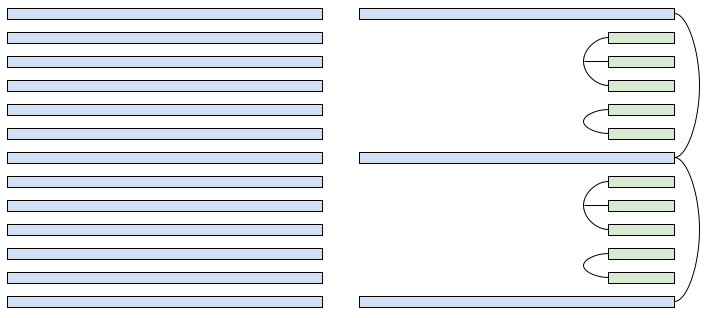


####    Summary:
    
Goal: reduce the KV cache size (since inference is memory-limited) without hurting accuracy
    
Lower-dimensional KV cache (GQA, MLA, shared KV cache)
    
Local attention on some of the layers

# alternatives_to_the_transformer(跳帧transformer结构优化infer)
## State-space models
这是一个关于**状态空间模型（State-space models, SSMs）**及其与 Transformer 架构结合的演变过程。核心思想是利用 SSMs 在处理长序列时的效率优势，同时弥补其在语言任务上的不足，最终构建出高性能且推理高效的语言模型。

---

### 1. 状态空间模型（SSMs）

* **基本思想**：SSMs 借鉴了信号处理中的概念，能以**亚二次方（sub-quadratic）** 的时间复杂度处理长序列。与 Transformer 的 $O(N^2)$ 复杂度相比，这在处理超长上下文时具有显著优势。
* **S4**：S4 (Structured State Space Models) 是一个早期的代表作，它在处理**合成长上下文任务**（例如音频生成）时表现出色。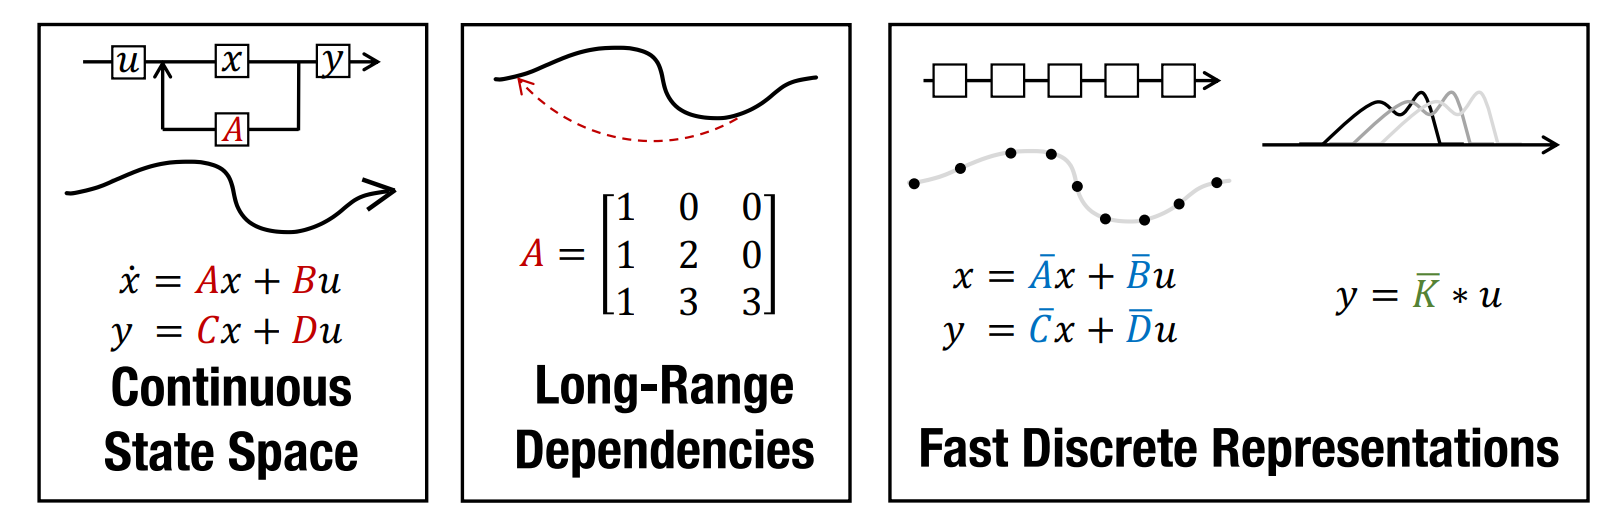
* **缺点**：S4 这类早期模型在处理语言任务时表现不佳，特别是在**联想记忆（associative recall）** 任务上。这类任务要求模型能够从大量信息中精确地回忆出特定细节，而这正是 Transformer 擅长的领域。
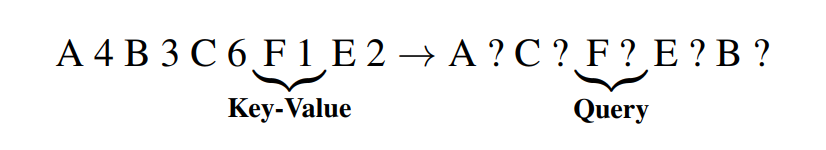
### 2. Mamba 模型的出现

* **核心创新**：Mamba 解决了 SSMs 的主要弱点。它通过引入**输入依赖（input-dependent）** 的参数，使得模型能够根据当前的输入动态调整其行为，从而更好地适应语言任务。
* **效果**：这使得 Mamba 在 10 亿参数级别上，能够与 Transformer 的性能相媲美。

### 3. 混合架构的演进

既然 SSMs 擅长处理长上下文且推理高效，而 Transformer 擅长联想记忆，那么一个自然的想法就是将两者结合。

* **Jamba**：该模型将 **Transformer 层与 Mamba 层以 1:7 的比例交错排列**，并结合了一个 **MoE (Mixture of Experts)** 架构。这种设计旨在结合 Mamba 的长上下文处理能力和 Transformer 的强大建模能力，以实现更高的性能。
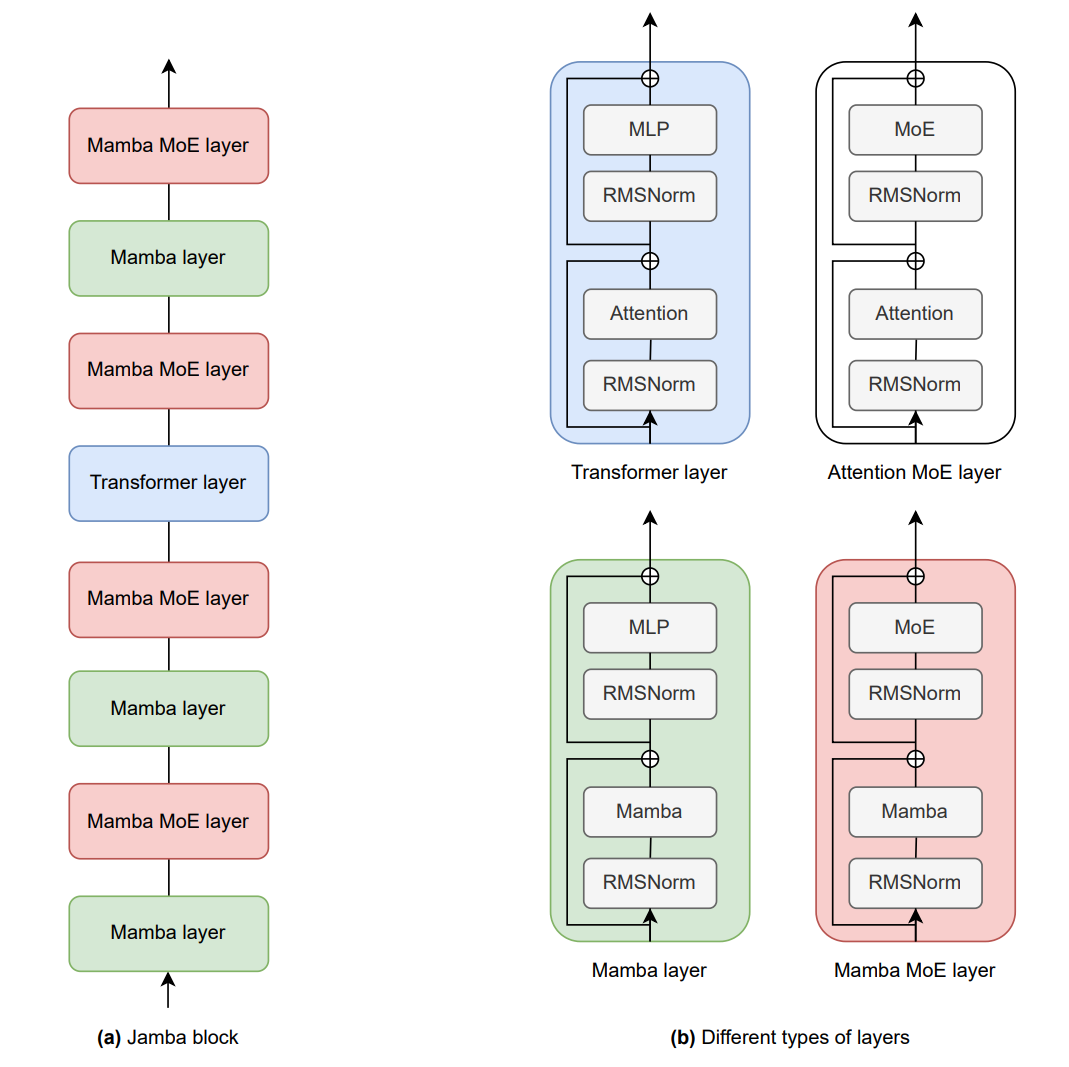
* **BASED**：这个模型采用了一种不同的混合策略，它结合了**线性注意力**和**局部注意力**。线性注意力将注意力机制的复杂度从 $O(N^2)$ 降低到 $O(N)$，而局部注意力则进一步优化了长序列推理。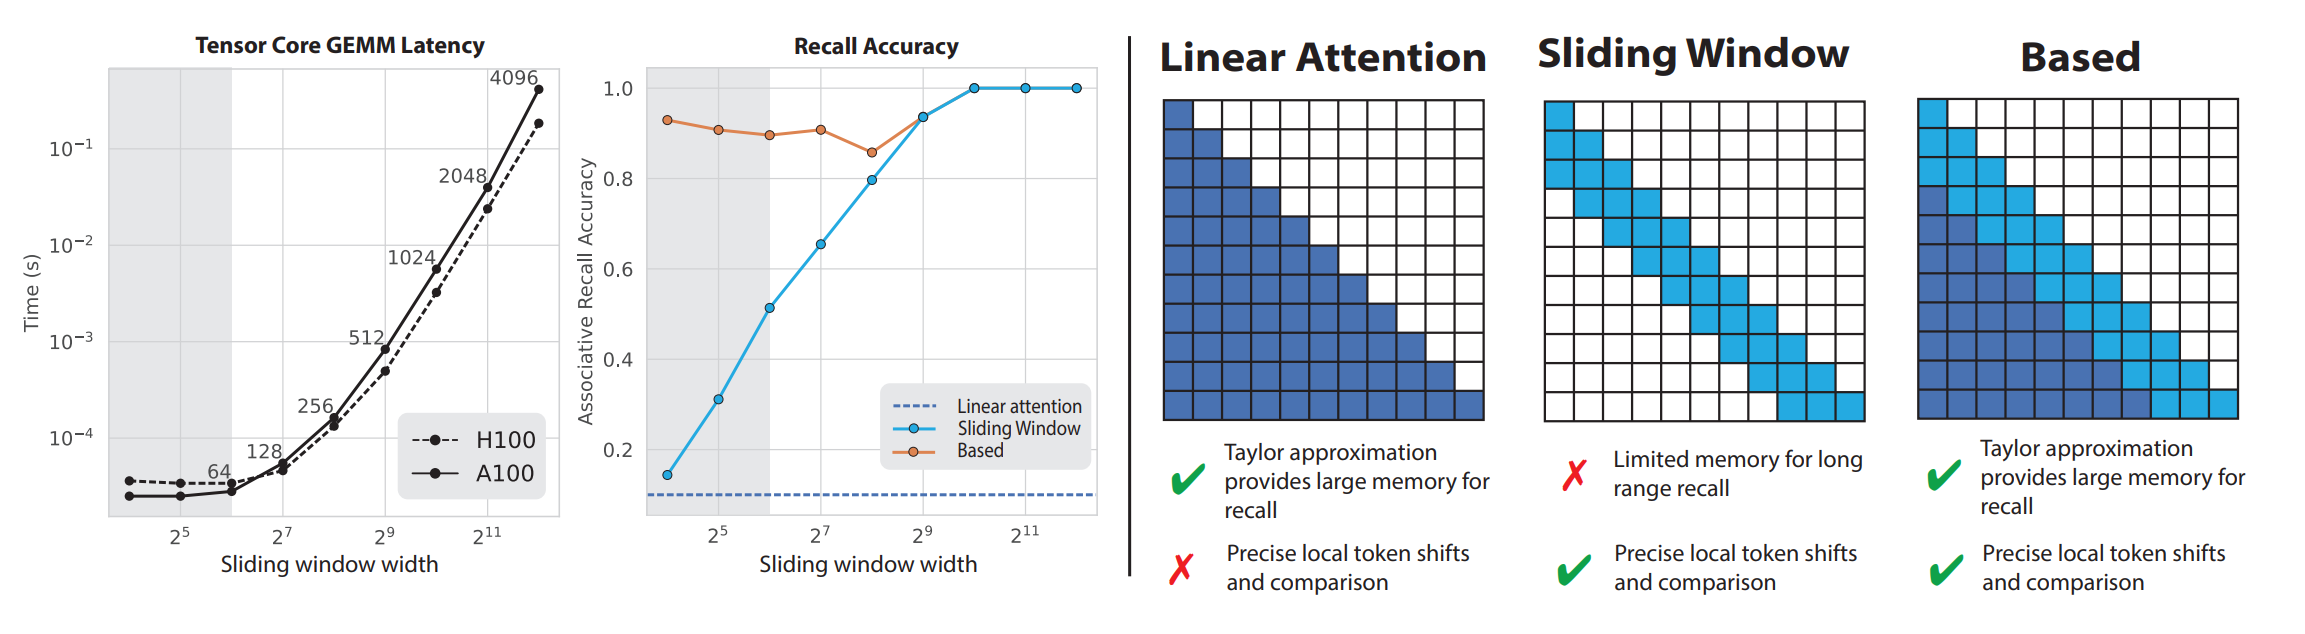
* **MiniMax-01**：该模型采用了**线性注意力**与**完整注意力（full attention）** 的混合方案，并且是一个拥有 4560 亿参数的 MoE 模型。这表明即使在线性注意力取得了进展的情况下，在某些关键层仍然需要完整的注意力来确保模型的性能。

### 4. 核心要点总结

* **混合是关键**：当前的 SOTA 模型不再是单一架构，而是**混合架构**。它们通常结合了**线性/局部注意力**和**完整的注意力**，或者结合了 **SSMs** 和 **Transformer**。
* **长上下文推理**：通过使用 SSMs 或线性注意力，可以将 KV 缓存从与序列长度相关的 $O(T)$ 复杂度，替换为**与序列长度无关的 $O(1)$ 状态**。这意味着推理效率大幅提升，尤其是在生成阶段。
* **平衡**：这些混合模型的核心思想是在**保持甚至超越 Transformer 性能**的同时，显著提高**推理效率**。通过在模型中策略性地保留一些全注意力层，可以弥补亚二次方模型在某些任务上的不足。



## difussion mudel



### 扩散模型的工作原理

* **基本思想**：扩散模型最初在图像生成领域大放异彩。其核心思想是，从一个完全随机的“噪声”状态开始，通过一系列迭代的“去噪”步骤，逐步将噪声转化为有意义的数据（如图像或文本）。

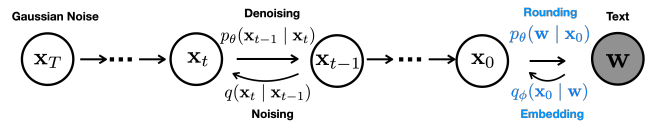
* **在文本生成中的应用**：与图像生成类似，文本扩散模型从一个**充满噪声的完整序列**（即一系列随机 token）开始。然后，它在多个时间步（time steps）内并行地对整个序列进行**迭代细化（iterative refinement）**。


* **速度提升**：由于其并行生成的特性，扩散模型在推理速度上具有巨大潜力。
* **挑战**：虽然在图像生成上取得了巨大成功，但将扩散模型应用于文本生成更为困难。原因在于：
    1.  **离散性（Discreteness）**：文本是离散的 token，而图像是连续的像素值。在离散空间中进行“去噪”和“细化”是一个更具挑战性的任务。
    2.  **语义一致性**：保持整个序列在迭代细化过程中的语义一致性，比在图像中保持视觉连贯性更难。



### quantization
Key idea: reduce the precision of numbers
Less memory means higher latency/throughput (since inference is memory-limited).
Of course we have to worry about accuracy...
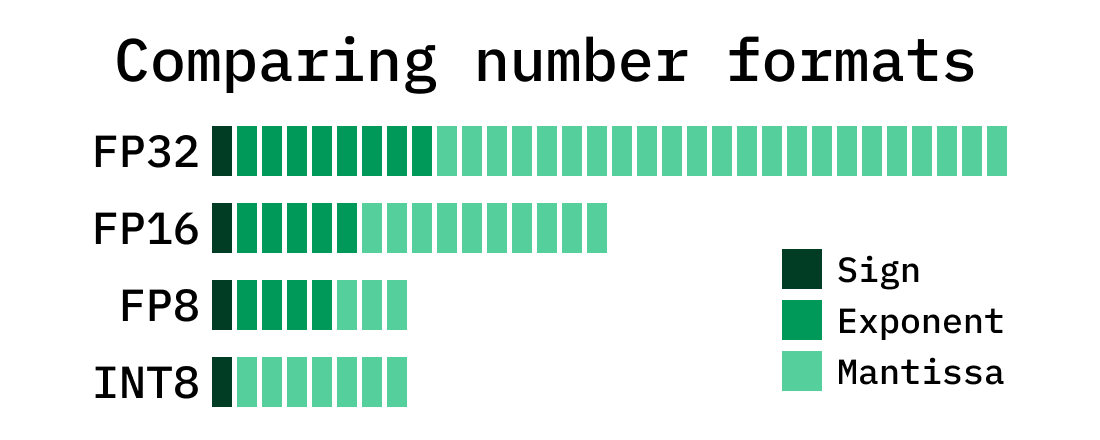

fp32 (4 bytes): needed for parameters and optimizer states during training
    
bf16 (2 bytes): default for inference
    
fp8 (1 byte) [-240, 240] for e4m3 on H100s: can train if you dare
 [Peng+ 2023]
    
int8 (1 byte) [-128, 127]: less accurate but cheaper than fp8, but for inference only
 [Baalen+ 2023]
    
int4 (0.5 bytes) [-8, 7]: cheaper, even less accurate
 [Baalen+ 2023]

 - Quantization-aware training (QAT): train with quantization, but doesn't scale up
 - Post-training quantization (PTQ): run on sample data to determine scale and zero point for each layer or tensor


LLM.int8() 是一种用于量化大型语言模型（LLM）的方法，它旨在通过将模型权重从全精度（如 FP16）转换为更低精度（如 INT8）来减少内存占用，同时解决量化中常见的**离群值（outliers）**问题。

---

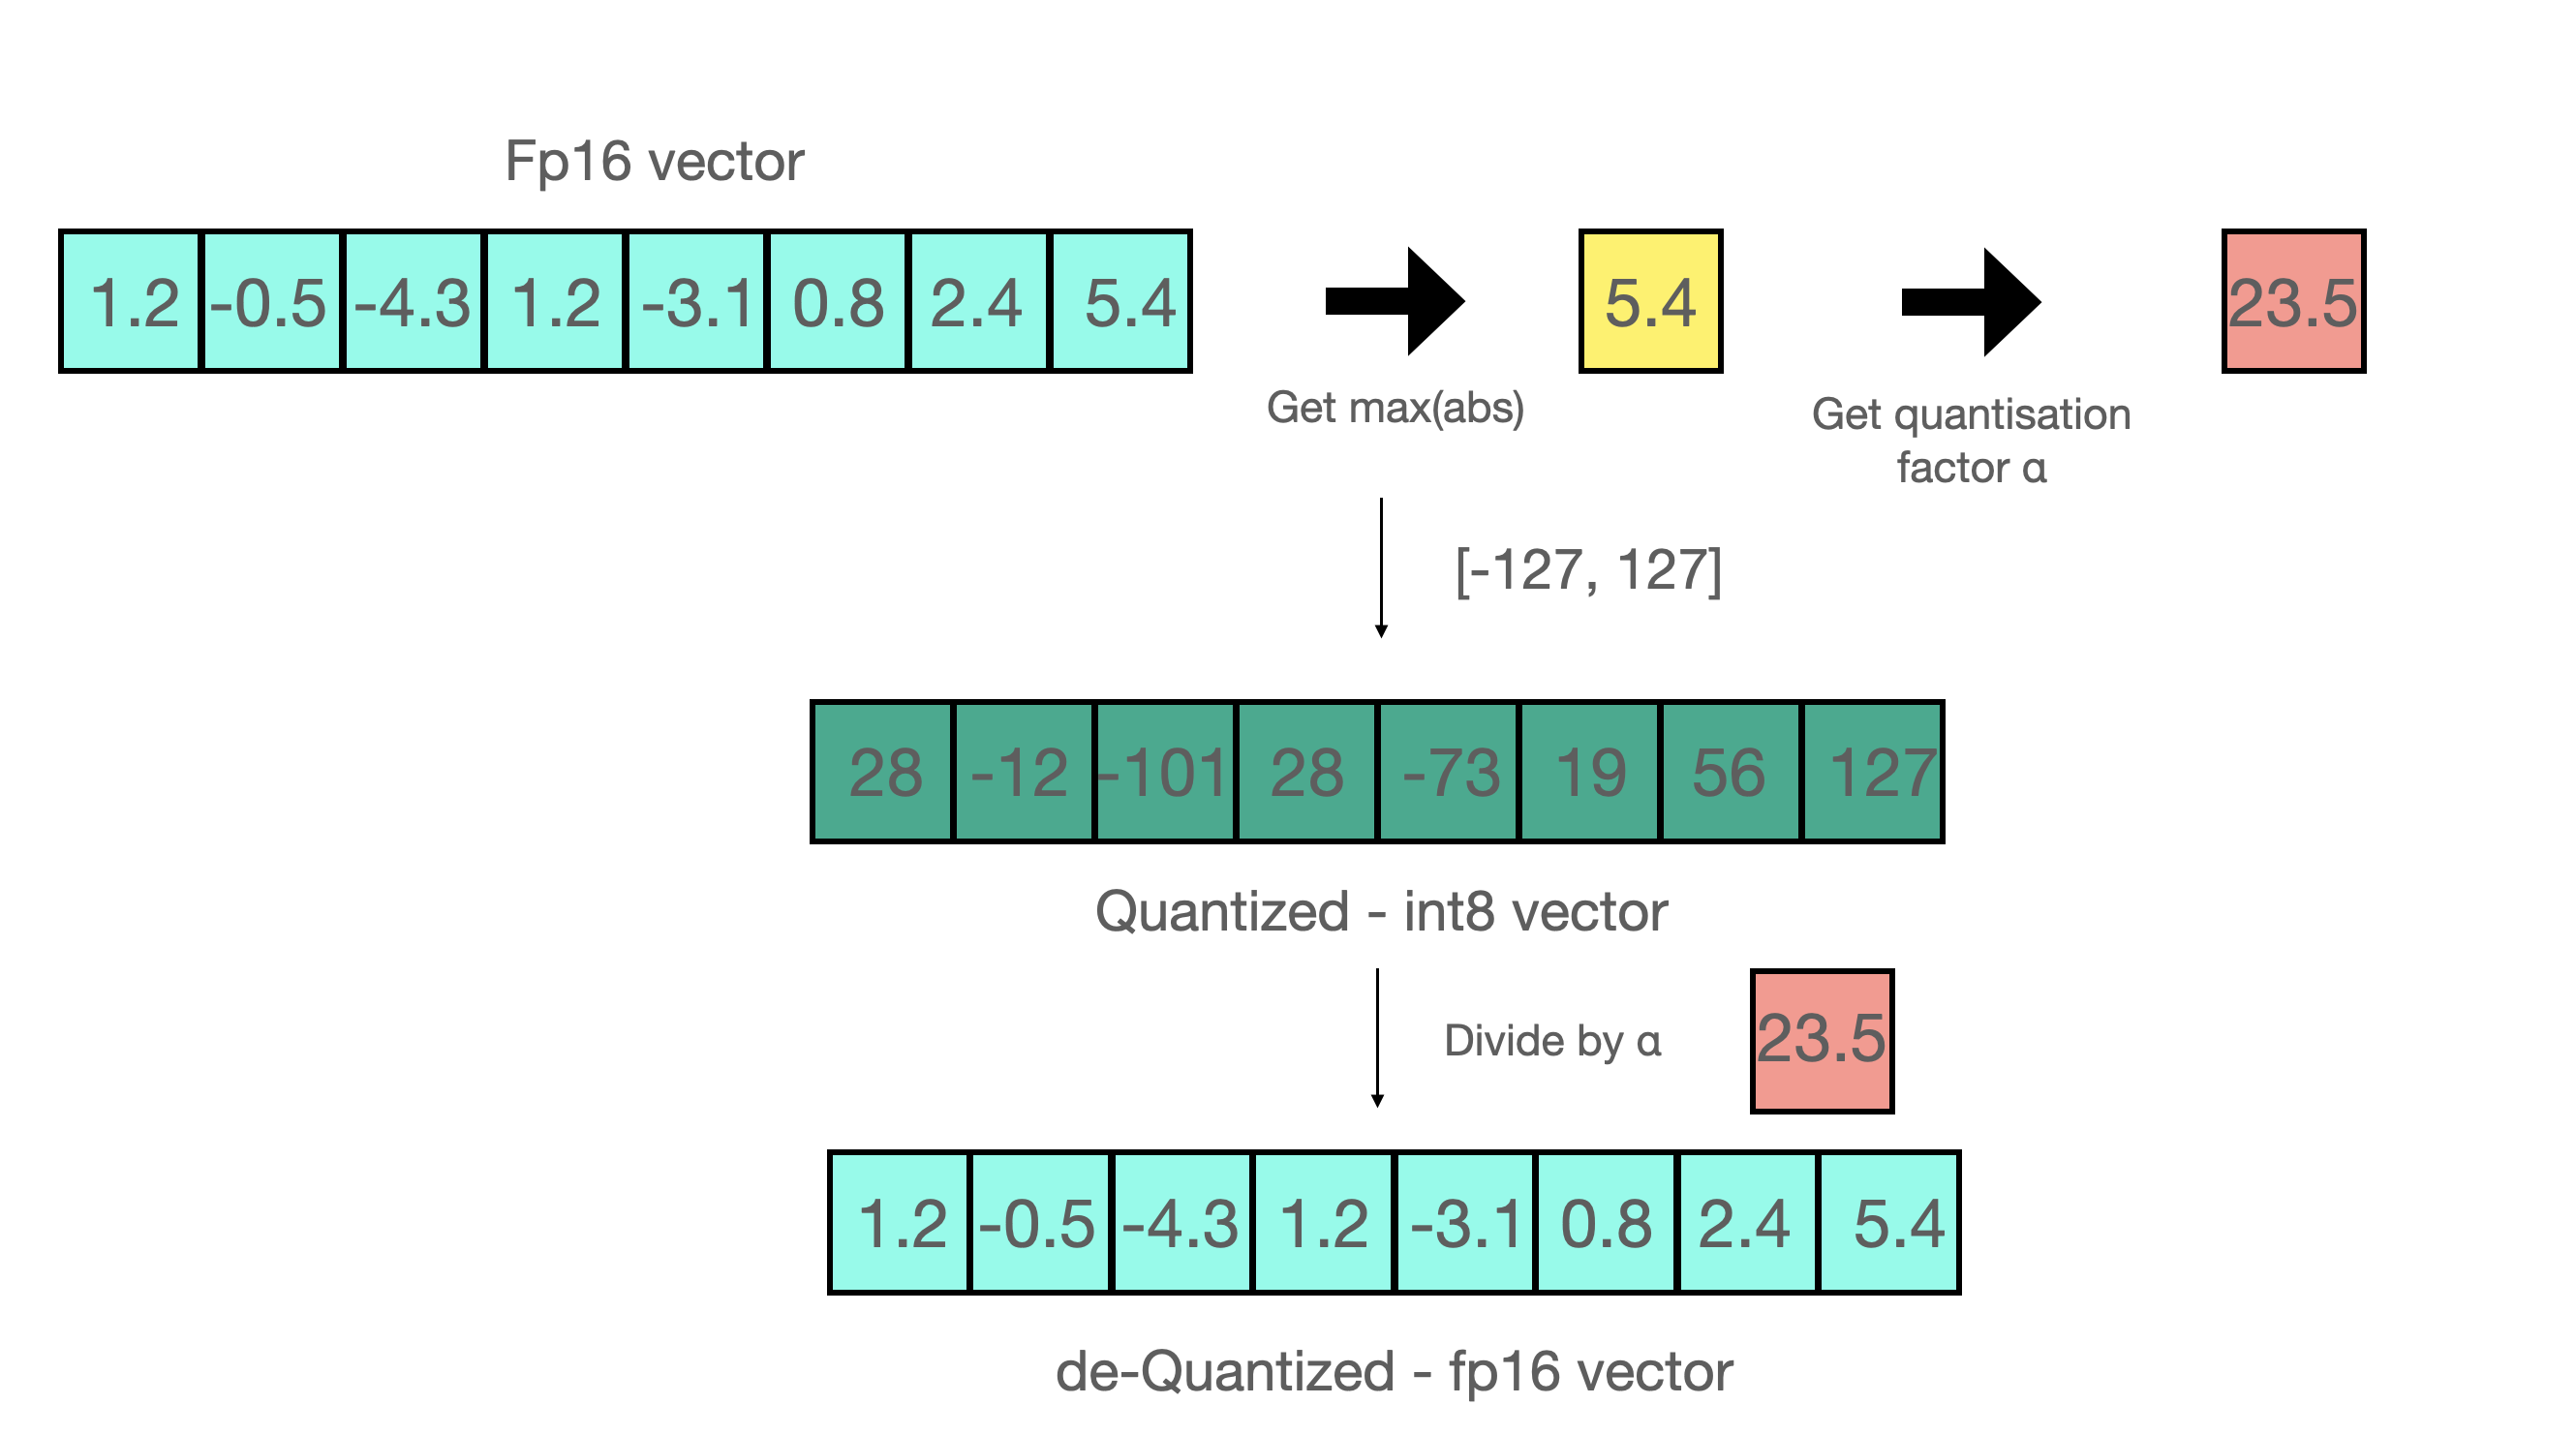
### LLM.int8() 的解决方案

* **核心思想**：LLM.int8() 的方法是**将离群值单独处理**，而对大部分非离群值进行标准量化。
* **具体步骤**：
    1.  **识别离群值**：通过设定一个阈值，识别出权重矩阵中那些绝对值特别大的数值。
    2.  **分离处理**：将这些离群值**提取**出来，并用**半精度（FP16）**格式进行计算，以保持其精度。
    3.  **量化其余部分**：对剩余的、没有离群值的权重张量部分进行标准的 INT8 量化。

### 效果与权衡

* **效果**：这种混合精度（Mixed-precision）的方法能够有效解决离群值问题，显著**减少内存占用**，同时**保持模型的性能**。这使得在消费级 GPU 上运行更大的模型成为可能。
* **性能**：尽管 LLM.int8() 成功地保持了模型的准确性，但由于需要额外地处理和计算离群值的 FP16 乘法，其推理速度会比纯 FP16 推理**慢 15-23%**。这种速度上的损失是与节省的内存空间和所获得的模型能力之间的权衡。



### Activation-aware quantization
    [Lin+ 2023]
    Idea: select which weights (0.1-1%) to keep in high precision based on activations
    fp16 -> int3 produces 4x lower memory, 3.2x speedup
标准量化：之前的量化方法（如 LLM.int8()）主要是根据权重的数值分布（例如离群值）来决定哪些部分保持高精度。

激活感知量化：该方法则更进一步，它考虑了激活值（activations）。其核心洞察是：即使某些权重本身数值不大，但如果它们经常与很大的激活值相乘，那么在乘积中产生的误差会被放大，从而影响模型的最终输出。

实现方法：该方法会根据模型运行时的激活值，识别出那些对模型输出影响最大的权重（通常只占总权重的 0.1-1%）。这些权重会被保留在半精度（FP16）中，而其余的绝大部分权重则被量化到更低的精度（如 INT3）。
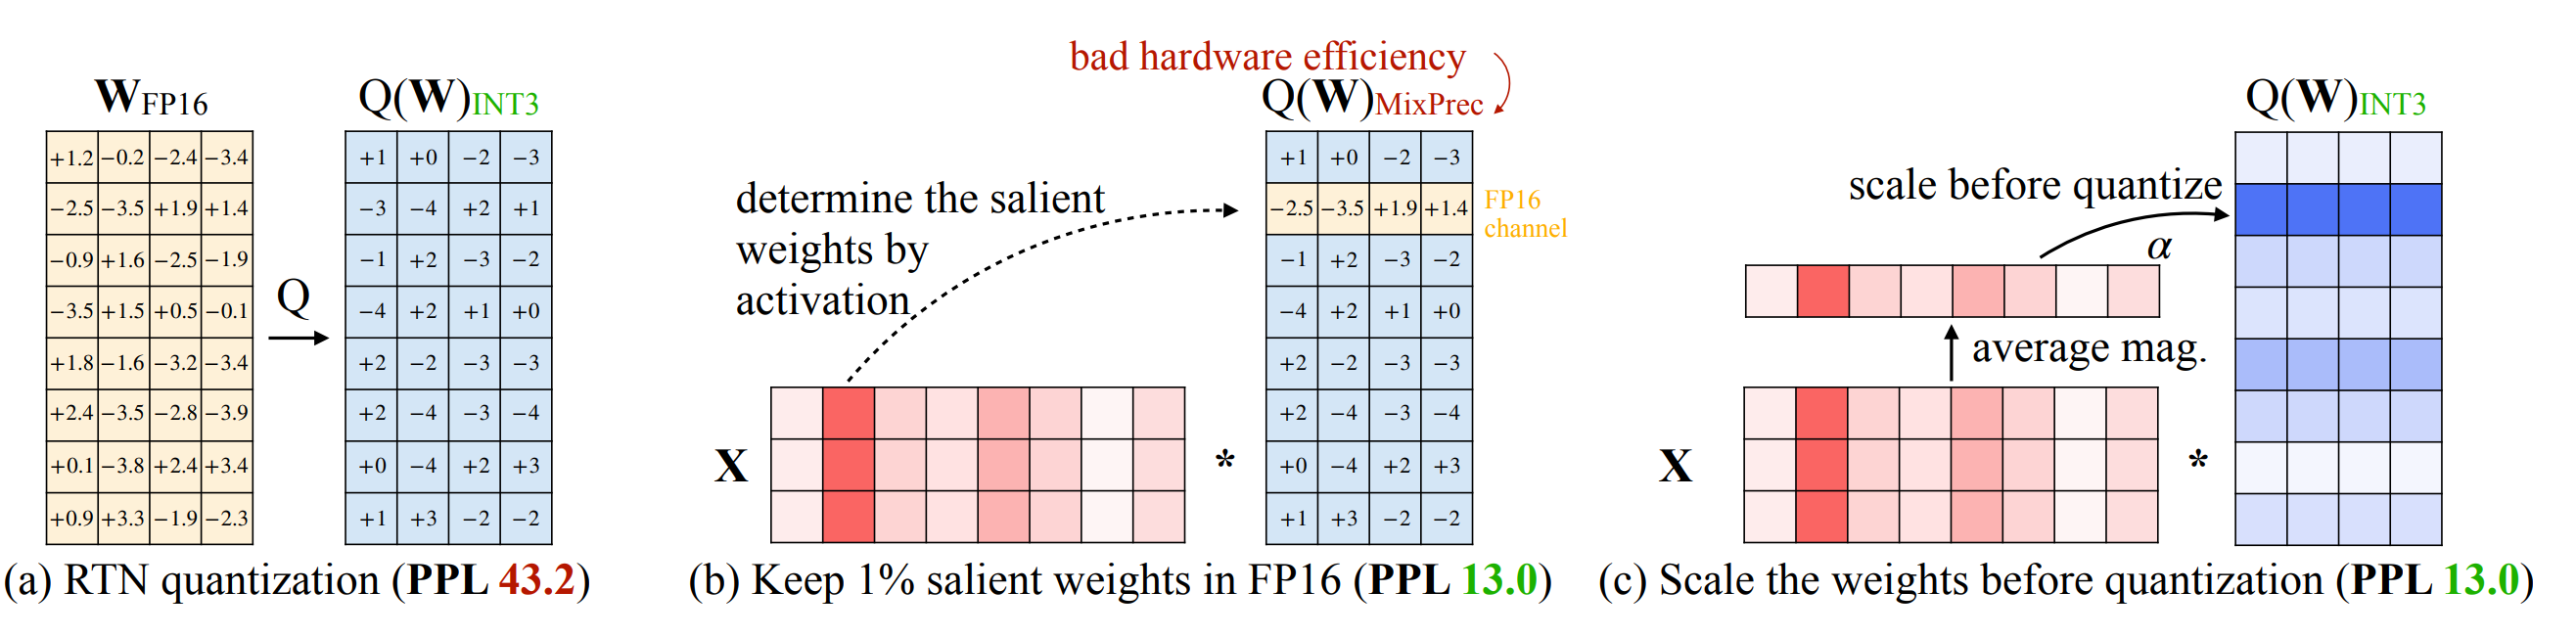

模型剪枝（Model Pruning）是一种优化技术，其核心思想是**移除大型模型中不重要的部分，使其变得更小、更快，然后通过某种方式恢复其性能**。

---

### 模型剪枝算法

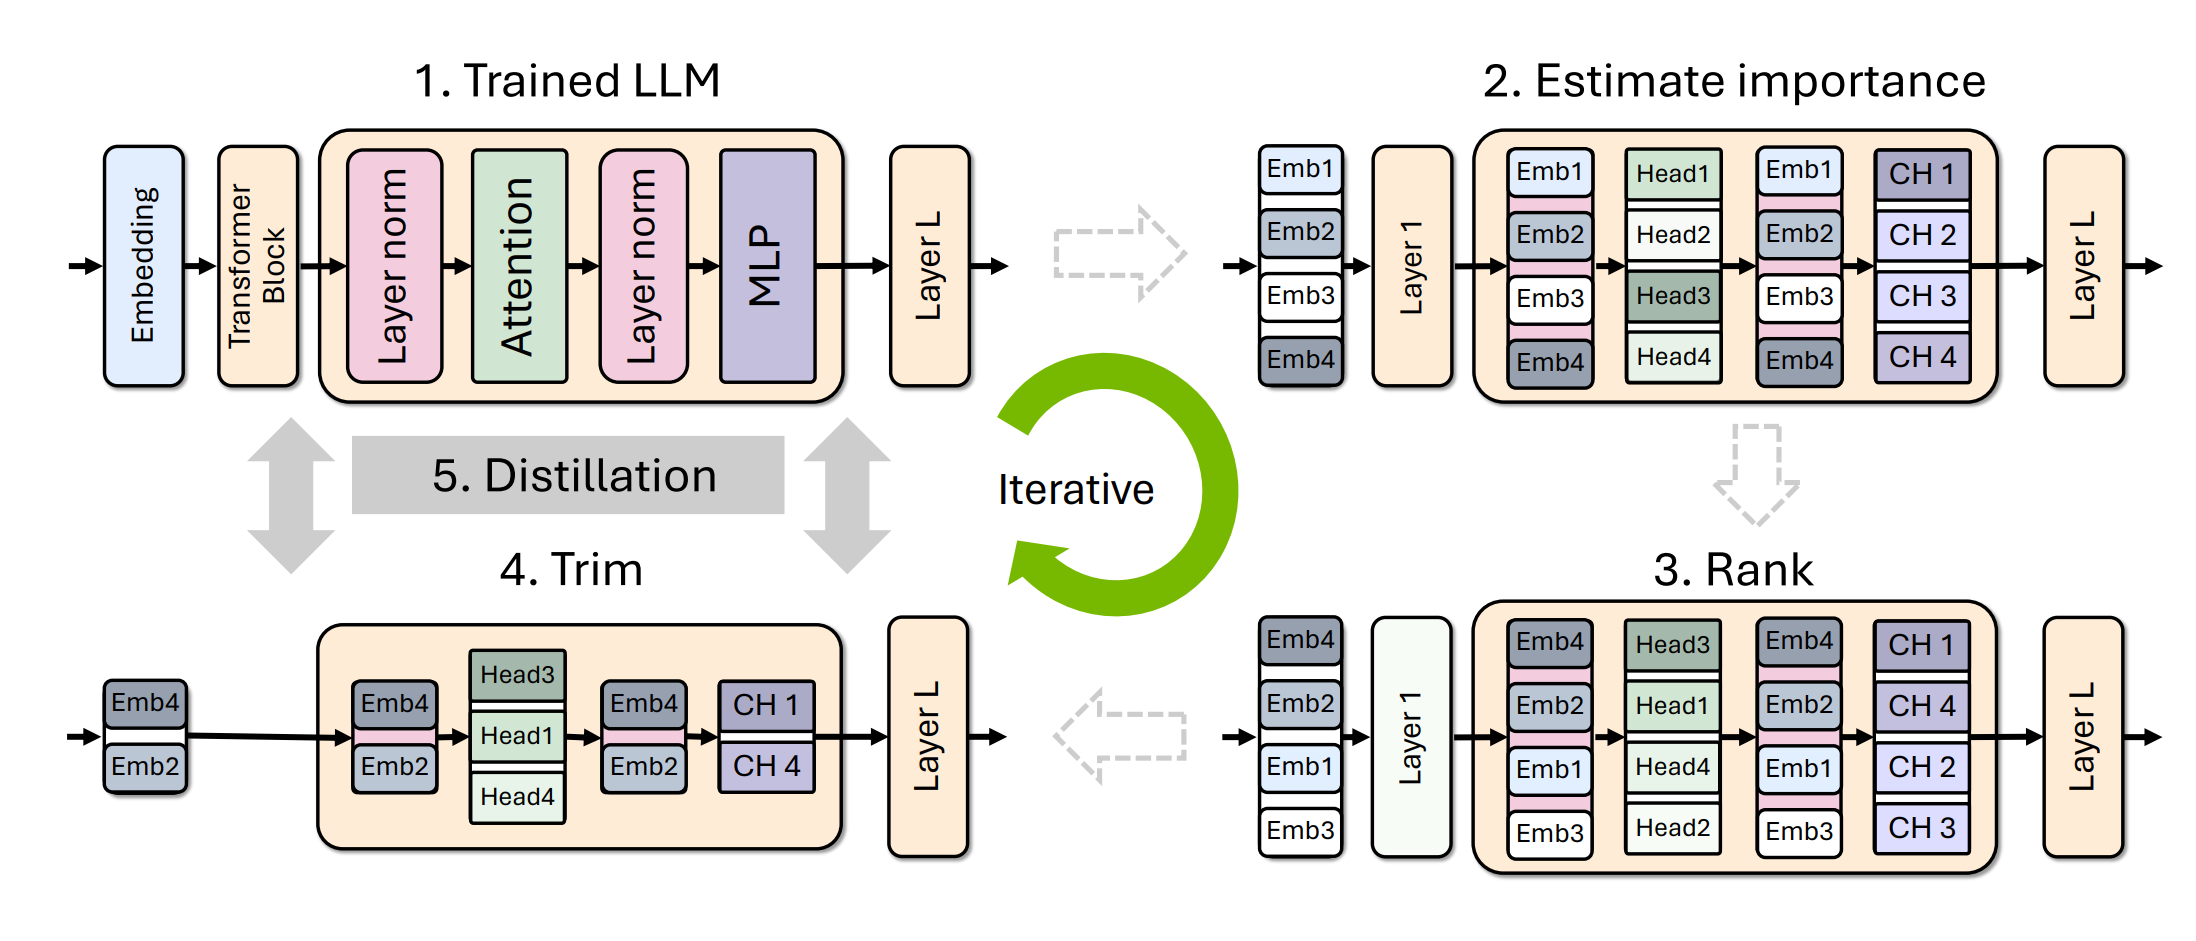
#### 1. 识别重要部分
* **目的**：找到模型中哪些部分（层、注意力头、隐藏维度）对最终性能贡献最大。
* **方法**：在一个小型的校准数据集（如 1024 个样本）上进行分析。通过计算不同组件的重要性分数，来识别对模型输出影响最小的冗余部分。例如，可以计算移除某个组件后，模型在校准集上的损失增加量。

#### 2. 移除不重要部分
* **目的**：根据第一步的分析结果，将不重要的部分从模型中移除。
* **具体操作**：
    * **层剪枝**：直接移除整个不重要的层。
    * **注意力头剪枝**：移除整个不重要的注意力头。
    * **隐藏维度剪枝**：在特定的层中，移除不重要的隐藏维度。
* **结果**：这一步得到一个更小、参数更少的模型，但其性能通常会严重下降。

#### 3. 知识蒸馏（Distillation）
* **目的**：修复因剪枝造成的性能损失，使小模型的性能接近原始大模型。
* **方法**：使用原始的、未经剪枝的“教师模型”（teacher model）来指导剪枝后的“学生模型”（student model）进行训练。教师模型会生成软标签（soft labels），学生模型的目标是模仿教师模型的输出分布，从而学习其知识和泛化能力。
* **结果**：经过知识蒸馏后，剪枝模型的性能得到恢复，有时甚至能超越直接从头训练的小模型。



### 不会对模型造成损害的方法：speculative sampling
视频https://storage.googleapis.com/gweb-research2023-media/media/SpeculativeDecoding-1-Illustration.mp4
Recall the two stages of inference:
    
 - Prefill: given a sequence, encode tokens in parallel (compute-limited) [note: also gives you probabilities]
    
 - Generation: generate one token at a time (memory-limited)
In other words, checking is faster than generation.

这是一份关于**推测性采样（Speculative Sampling）**的笔记，它是一种旨在加速大语言模型（LLM）推理的技术，特别针对生成阶段（Generation）的内存瓶颈问题。



#### 1. 推理过程的瓶颈

在大型语言模型推理中，有两个主要阶段：

* **预填充（Prefill）**：给定一个完整的提示序列，模型并行地处理所有 token 以生成第一个输出 token。这个阶段是**计算密集型（compute-limited）**的，因为它涉及大量的矩阵乘法。
* **生成（Generation）**：模型一次生成一个 token。这个阶段是**内存密集型（memory-limited）**的，因为它需要频繁地从显存中读取 KV 缓存。

推测性采样的核心洞见是：**验证（checking）比生成要快得多**。并行处理几个 token（验证）的速度远快于一个一个地生成它们。

#### 2. 推测性采样的核心思想

推测性采样的目标是利用“验证快于生成”的特性来加速推理。

* **草稿模型（Draft Model）**：使用一个更小、更便宜、推理速度更快的“草稿模型” $p$ 来**预测**（推测性地生成）接下来的一小段序列（例如 4 个 token）。
* **目标模型（Target Model）**：用原始的、更大、更精确的“目标模型” $q$ 来**验证**草稿模型生成的这些 token。目标模型可以并行地处理这些 token，并检查其概率。
* **接受/拒绝**：如果草稿模型的预测与目标模型的概率分布匹配，则接受这些 token。如果不匹配，则拒绝不匹配的部分，并让目标模型从不匹配的那个 token 开始重新生成。
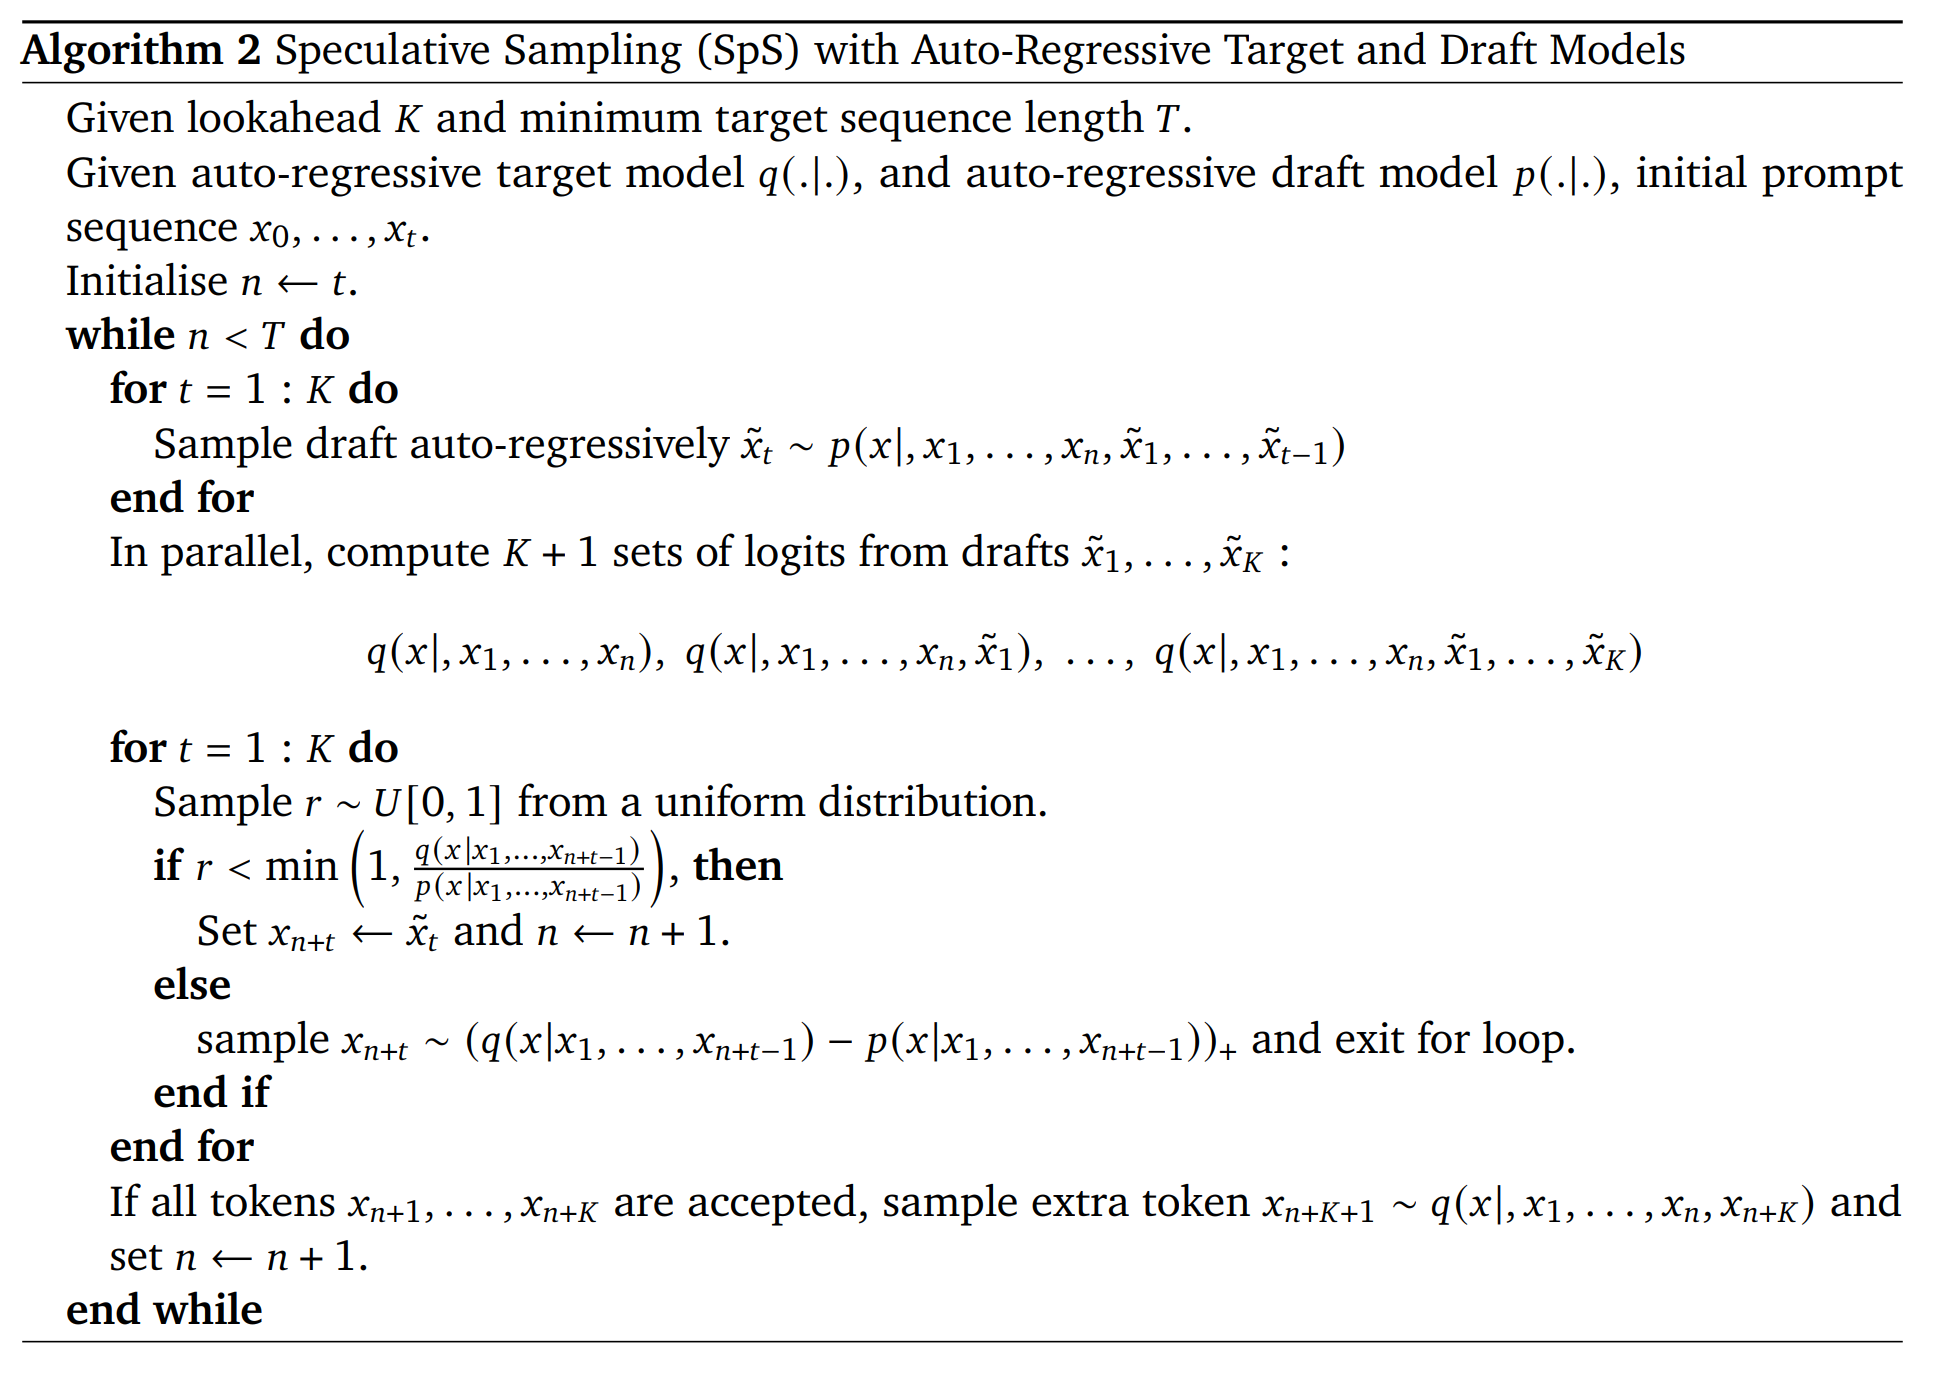
#### 3. 数学原理：确保**精确采样**

推测性采样最关键的性质是：它**保证**最终的输出序列**完全等同于**使用原始目标模型逐一生成的序列，即从 $q$ 的概率分布中精确采样。

这是通过一个巧妙的**接受/拒绝（rejection sampling）**机制实现的：

* 对于草稿模型生成的每个 token $x_i$，目标模型会计算一个接受概率 $\min(1, \frac{q(x_i)}{p(x_i)})$。
* 如果接受，则保留该 token。
* 如果拒绝，则从一个**残差分布** $q'(x_j) \propto \max(0, q(x_j) - p(x_j))$ 中重新采样一个 token。
* 这种设计通过数学保证了最终的采样分布仍然是目标模型 $q$ 的分布。
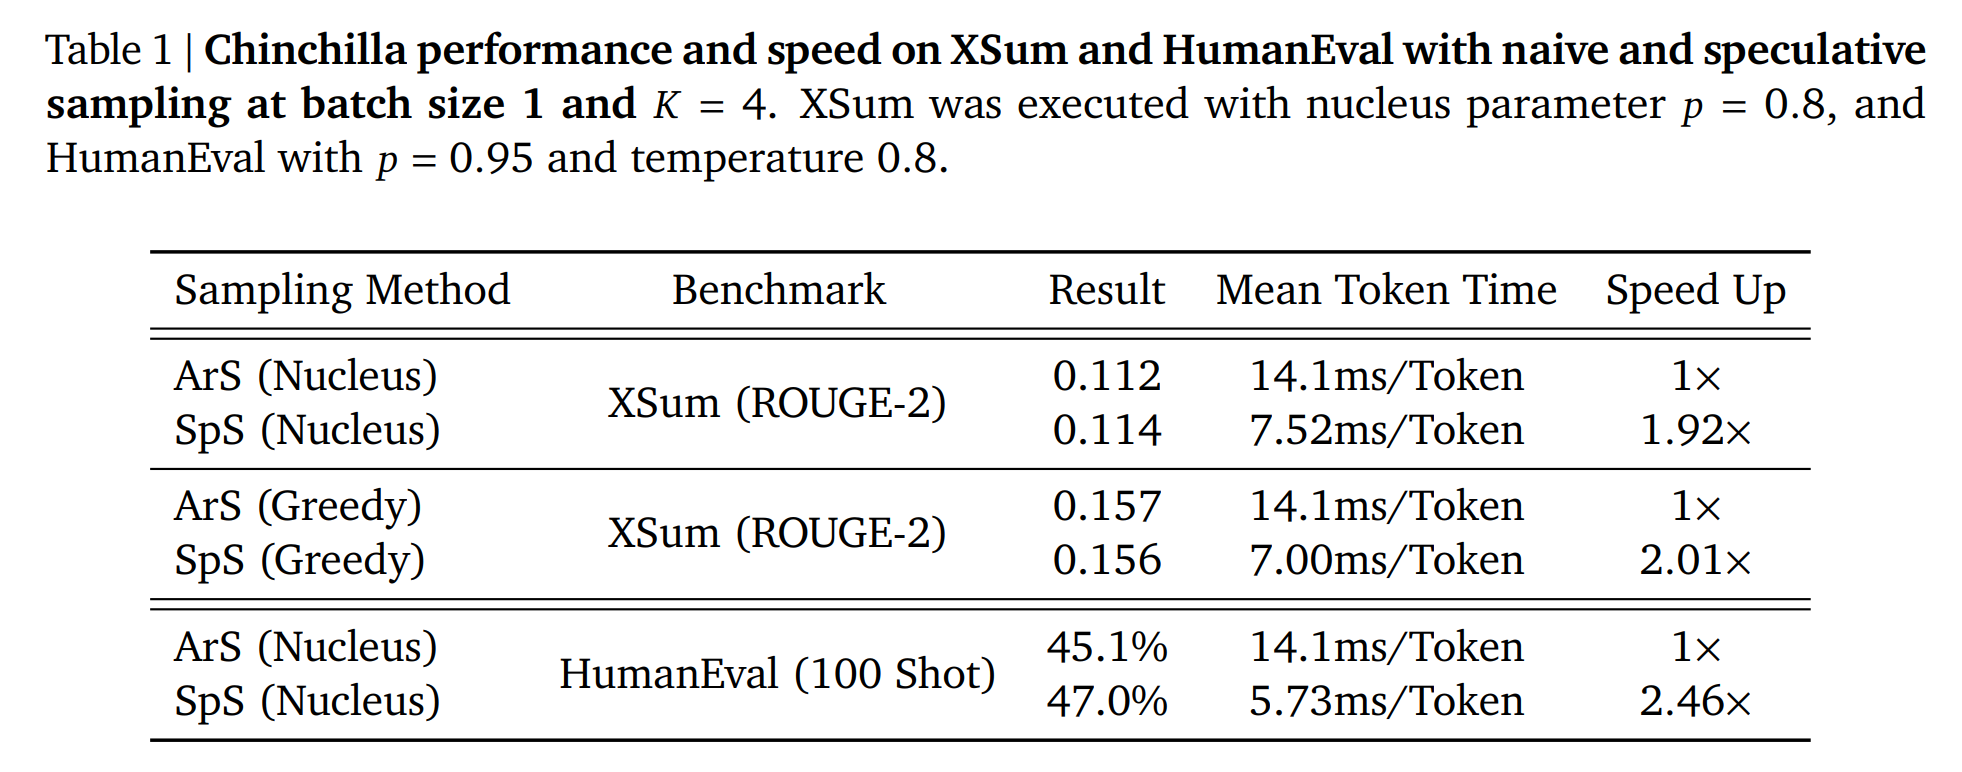
#### 4. 实际应用与扩展

* **模型选择**：    
Target model has 70B parameters, draft model has 8B parameters
    
Target model has 8B parameters, draft model has 1B parameters
    
Try to make draft model as close to target (distillation)
* **Medusa**：一种更激进的推测性采样扩展。它让草稿模型**并行地**生成多条路径的多个 token，从而进一步提升推测效率。
* **EAGLE**：另一种扩展，它让草稿模型从目标模型中获取**高层次特征**，从而更准确地预测接下来的 token。



### Continuous Batching
连续批处理，也称为动态批处理（Dynamic Batching），通过**迭代级别的调度（iteration-level scheduling）**解决了上述问题。

工作原理：

系统逐个解码 token，而不是等待整个序列生成完毕。

当新的请求到达时，它们会被立即添加到当前的批处理队列中，而无需等待前一批次的所有请求完成。

这种方法让 GPU 保持忙碌状态，显著提高了吞吐量和 GPU 利用率。

#### 另一个问题：如何处理不同长度的序列
Paper that introduced vLLM in addition to PagedAttention  [Kwon+ 2023]
    Previous status quo:
    
Request comes in
    
Allocate section of KV cache for prompt and response (up to a max length)
    
    Problem: fragmentation (what happens to your hard drive)
    
But this is wasteful since we might generate much fewer tokens (internal fragmentation)!
    
Might be extra unused space between sections (external fragmentation)!
    Solution: PagedAttention (remember operating systems)
    
Divide the KV cache of a sequence into non-contiguous blocks
    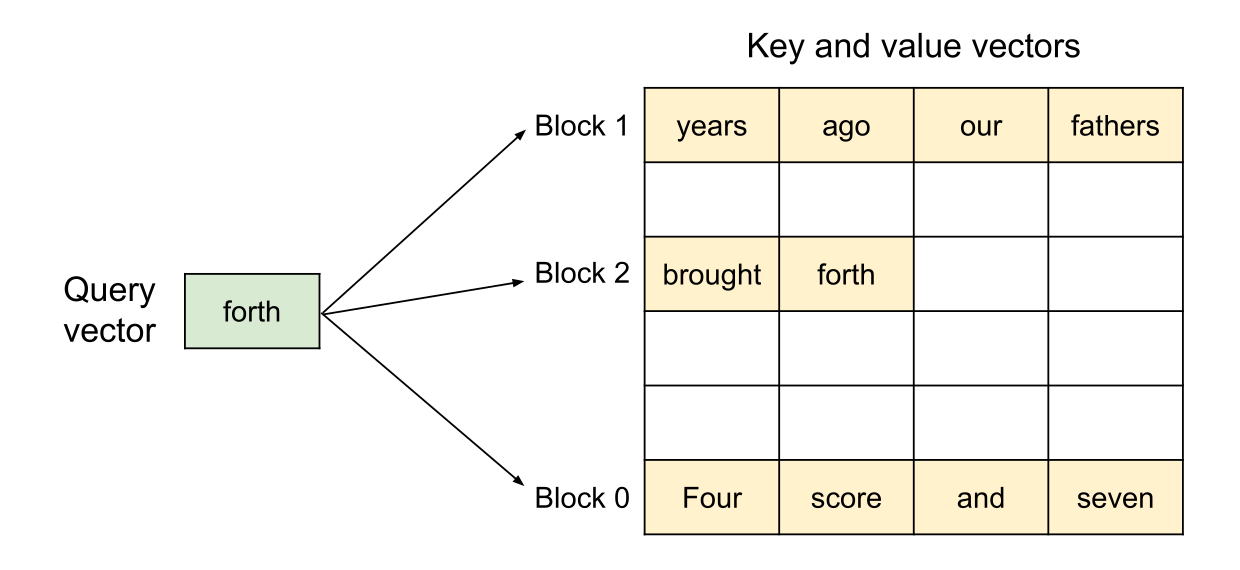
    Two requests share the KV caches:
    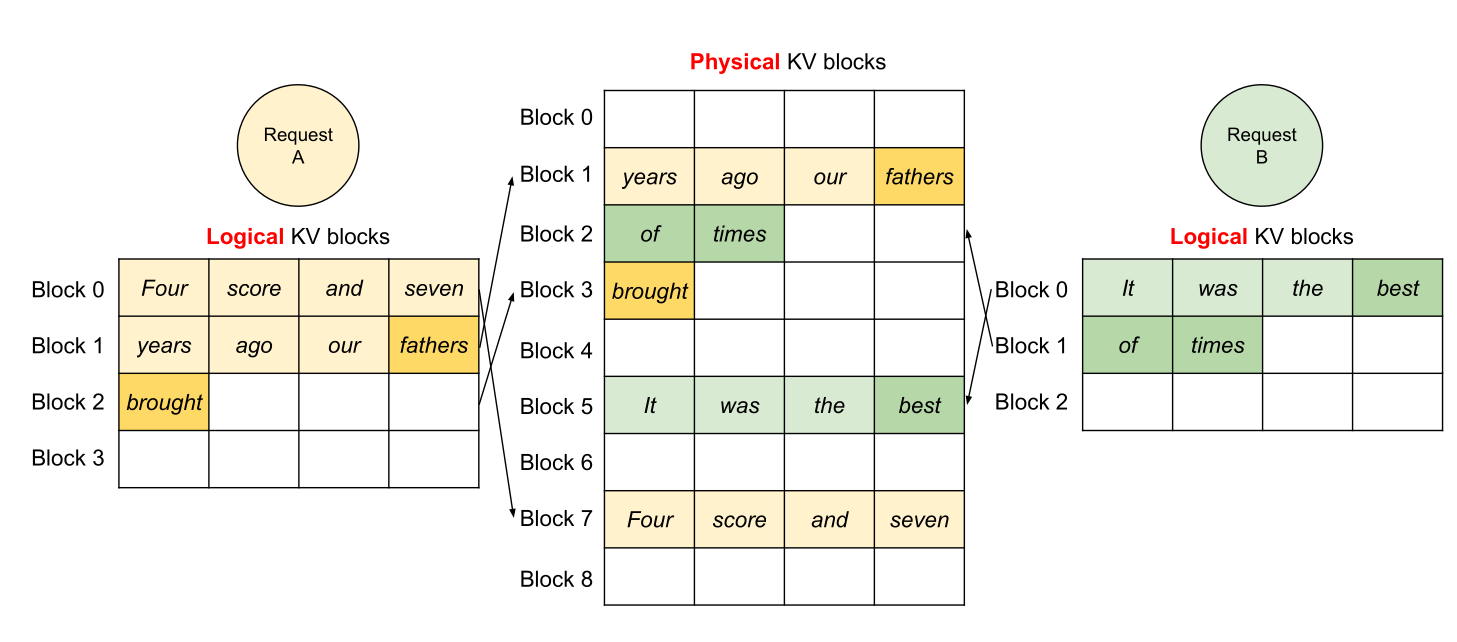
    In general, multiples types of sharing KV caches across sequences:
    
   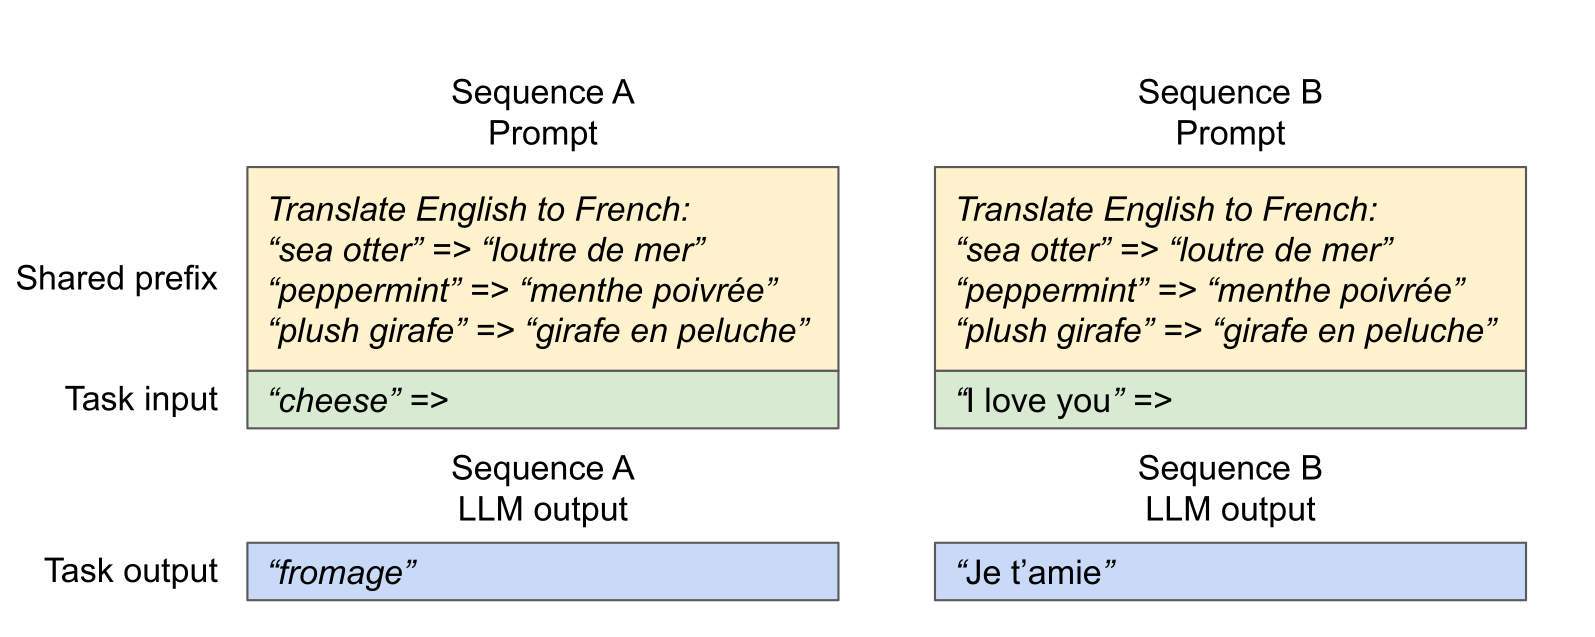 
Sharing the system prompt
    
Sampling multiple responses per prompt (e.g., for program synthesis)
    Solution: share prefixes, copy-on-write at the block level
    
    Other vLLM optimizations:
    
Kernel to fuse block read and attention (reduce kernel launch overhead)
    
Use latest kernels (FlashAttention, FlashDecoding)
    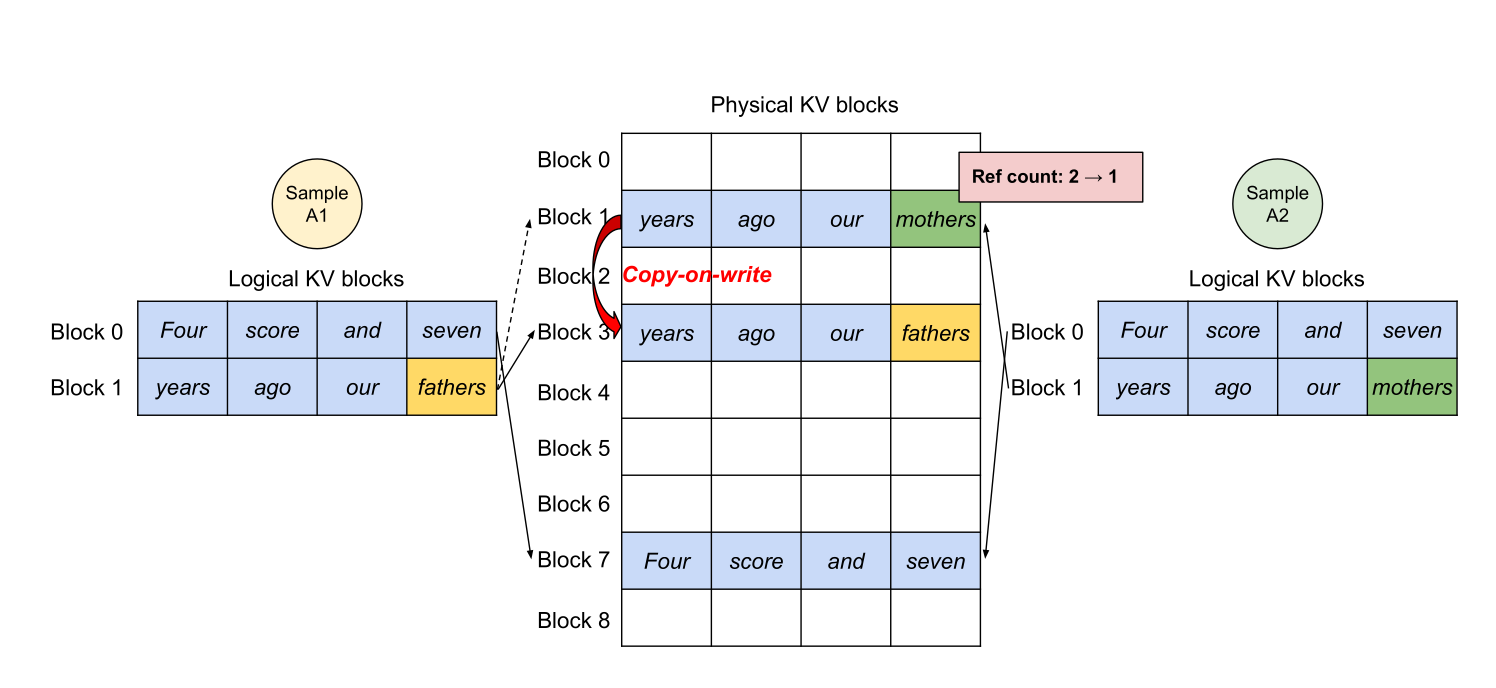
Use CUDA graphs to avoid kernel launch overhead
    Summary: use ideas from operating systems (paging) to make use of memory for dynamic workloads
